# Context

Churn dataset contains client information of a classified bank, located in Russian Federation. Thus, some features might not be well formatted. More specifically, marital_status, job_position, tariff_id, region are labeled and not categorized. Data source obtained from [Kaggle](https://www.kaggle.com/datasets/ilya2raev/bank-churn-dataset).

# Objective

To perform: 
- Logistic regression modelling
- Nonlinear modeling with XGBoost
- Lift analysis
- Profit optimization

# Data Description

- gender: Male or Female
- age: Age in years
- marital_status: Uncategorized martial status
- job_position: Uncategorized job position
- credit_sum: Sum of a credit
- credit_length: Loan term
- scoring: Internal bank scoring
- education: Education level
- tariff_id: Current banking tariff (uncategorized)
- region: Client region residence
- average_region_wage: Average monthly region wage (RUB)
- income: Monthly income (RUB)
- credit_count: Number of credits client is currently having
- overdue_count: Number of overdue loans
- churn: Target value


# Libraries and functions required

## Libraries

In [101]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores and split data
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    recall_score,
    average_precision_score,
    roc_curve,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold, 
)


# Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


# To build models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


import shap

import joblib
import os

import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)
# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)    
# setting the precision of floating numbers to 2 decimal points
pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Functions

### Plots

In [2]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [3]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [4]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [5]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

# Load data

In [9]:
data = pd.read_csv("Churn.csv")
df = data.copy()

# Analysis

## Data Overview

In [10]:
df.head()

,gender,age,marital_status,job_position,credit_sum,credit_length,scoring,education,tariff_id,region,average_region_wage,income,credit_count,overdue_count,churn
0,Female,48,3.00,15,59998.00,10,0.77,2.00,28,23.00,25850.00,30000.00,1.00,1.00,0
1,Male,28,NaN,15,10889.00,6,0.25,2.00,2,30.00,66880.00,43000.00,2.00,0.00,0
2,Female,32,3.00,14,10728.00,12,0.46,4.00,2,64.00,23430.00,23000.00,5.00,0.00,0
3,Male,27,2.00,14,12009.09,12,0.36,2.00,2,8.00,23650.00,17000.00,2.00,0.00,0
4,Female,45,3.00,14,16908.89,10,0.42,4.00,2,77.00,26620.00,NaN,1.00,0.00,0


In [11]:
df.shape

(170744, 15)

In [12]:
df.duplicated().sum()

np.int64(1151)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(169593, 15)

In [15]:
df.isnull().sum()

gender                    0
age                       0
marital_status            5
job_position              0
credit_sum                1
credit_length             0
scoring                   3
education                 3
tariff_id                 0
region                  189
average_region_wage     189
income                    2
credit_count           9190
overdue_count          9190
churn                     0
dtype: int64

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,169593.00,36.50,10.55,18.00,28.00,34.00,43.00,71.00
marital_status,169588.00,3.20,0.74,1.00,3.00,3.00,4.00,5.00
job_position,169593.00,13.16,3.13,1.00,14.00,14.00,14.00,18.00
credit_sum,169592.00,26077.63,16227.07,2736.00,14907.95,21220.00,32028.00,200000.00
credit_length,169593.00,10.98,3.54,3.00,10.00,10.00,12.00,36.00
scoring,169590.00,0.47,0.12,0.00,0.38,0.46,0.55,1.13
education,169590.00,3.20,1.06,1.00,2.00,4.00,4.00,5.00
tariff_id,169593.00,14.12,11.54,1.00,2.00,19.00,28.00,33.00
region,169404.00,43.01,22.22,1.00,25.00,40.00,63.00,82.00
average_region_wage,169404.00,32962.28,12578.22,16830.00,25520.00,27390.00,42460.00,66880.00


- `Age` range is between 18 to 71 years old. With an average of 36 years old.
- 5 `marital_status`, average to be the at 3rd marital status category.
- 18 different `job_position`, looks like majority are at category 14.
- `credit_sum` capped at RUB 200,000 unit currency. On average customer credit sum is at RUB 26,077 unit currency.
- `credit_length` capped at 36 months, minimum of 3 months, averages at 10 months.
- `scoring` ranges between 0.12 to 1.128, averages at 0.46.
- 5 `education` level, majority is at category 4.
- `tariff_id` 33 different tariff ID.
- `region` total of 82.
- `average_region_wage` minimum of RUB 16,830 upto a maximum of RUB 66,880.
- `income` per month at a minimum of RUB 25,026 to a maximum of RUB 950,000, averages at RUB 40,125.
- `credit_count` the number of credits client is having ranges between 0 to 21. Average 2 credits per client.
- `overdue_count` at most 3 counts, but averaged at 0.

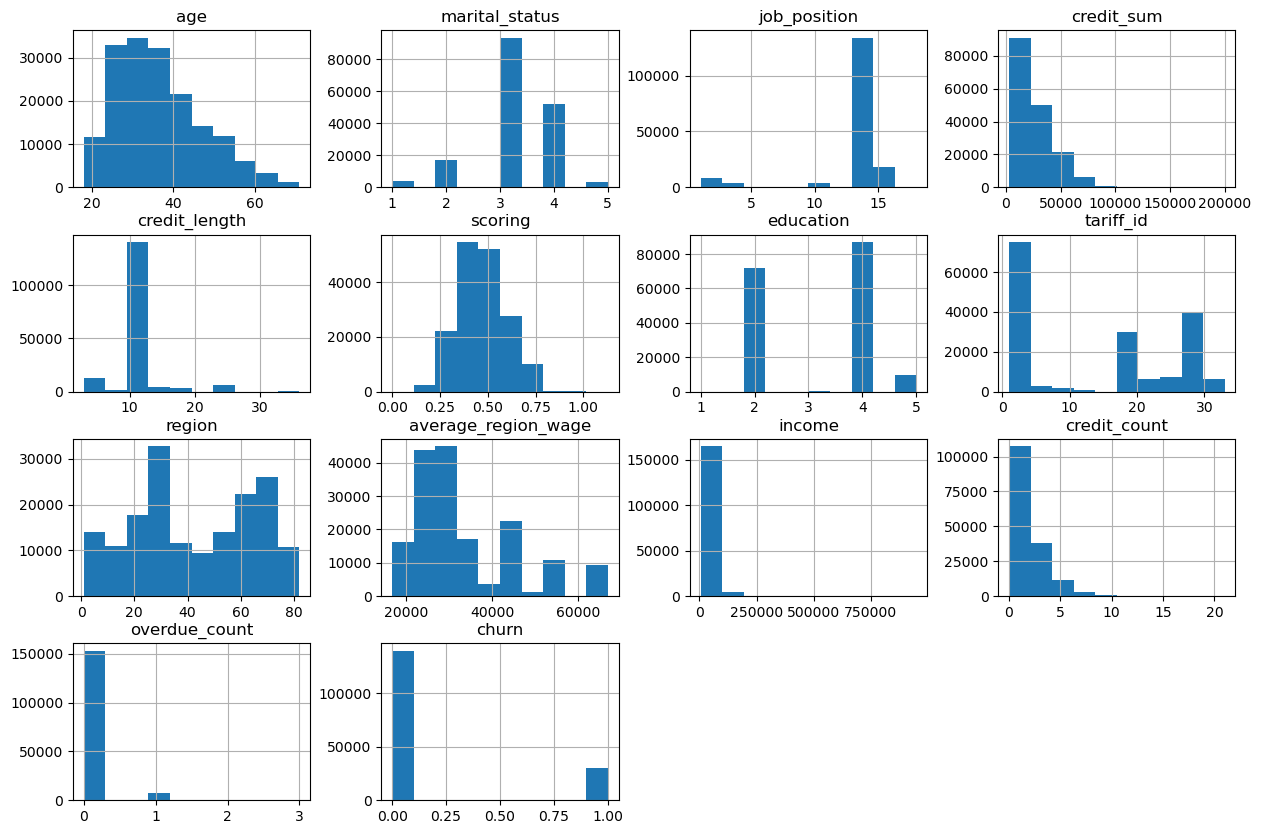

In [17]:
df.hist(figsize=(15,10))
plt.show()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169593 entries, 0 to 170743
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               169593 non-null  object 
 1   age                  169593 non-null  int64  
 2   marital_status       169588 non-null  float64
 3   job_position         169593 non-null  int64  
 4   credit_sum           169592 non-null  float64
 5   credit_length        169593 non-null  int64  
 6   scoring              169590 non-null  float64
 7   education            169590 non-null  float64
 8   tariff_id            169593 non-null  int64  
 9   region               169404 non-null  float64
 10  average_region_wage  169404 non-null  float64
 11  income               169591 non-null  float64
 12  credit_count         160403 non-null  float64
 13  overdue_count        160403 non-null  float64
 14  churn                169593 non-null  int64  
dtypes: float64(9), int64(5

In [19]:
convert_dict = {
    'marital_status': object,
    'job_position' : object,
    'education': object,
    'tariff_id': object,
    'region': object,
    'churn': object,
}

df = df.astype(convert_dict)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169593 entries, 0 to 170743
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               169593 non-null  object 
 1   age                  169593 non-null  int64  
 2   marital_status       169588 non-null  object 
 3   job_position         169593 non-null  object 
 4   credit_sum           169592 non-null  float64
 5   credit_length        169593 non-null  int64  
 6   scoring              169590 non-null  float64
 7   education            169590 non-null  object 
 8   tariff_id            169593 non-null  object 
 9   region               169404 non-null  object 
 10  average_region_wage  169404 non-null  float64
 11  income               169591 non-null  float64
 12  credit_count         160403 non-null  float64
 13  overdue_count        160403 non-null  float64
 14  churn                169593 non-null  object 
dtypes: float64(6), int64(2

In [20]:
cat_columns = df.describe(include=['object']).columns
cat_columns

for i in cat_columns:
    print("Unique values in", i, "are :")
    print(df[i].value_counts())
    print("-" * 50)

Unique values in gender are :
gender
Male      88097
Female    81496
Name: count, dtype: int64
--------------------------------------------------
Unique values in marital_status are :
marital_status
3.00    93306
4.00    51827
2.00    16836
1.00     4167
5.00     3452
Name: count, dtype: int64
--------------------------------------------------
Unique values in job_position are :
job_position
14    133711
15     17591
2       5549
10      4090
4       3727
1       2778
17       653
8        537
16       351
6        240
3        125
18       110
11        65
13        40
12        12
5          8
7          5
9          1
Name: count, dtype: int64
--------------------------------------------------
Unique values in education are :
education
4.00    86986
2.00    72046
5.00     9890
3.00      561
1.00      107
Name: count, dtype: int64
--------------------------------------------------
Unique values in tariff_id are :
tariff_id
2     68892
28    38764
19    15490
20    10880
25     7452
3

## Exploratory Analysis

### Univariate

In [21]:
num_columns = df.describe(include=np.number).columns
num_columns

Index(['age', 'credit_sum', 'credit_length', 'scoring', 'average_region_wage',
       'income', 'credit_count', 'overdue_count'],
      dtype='object')

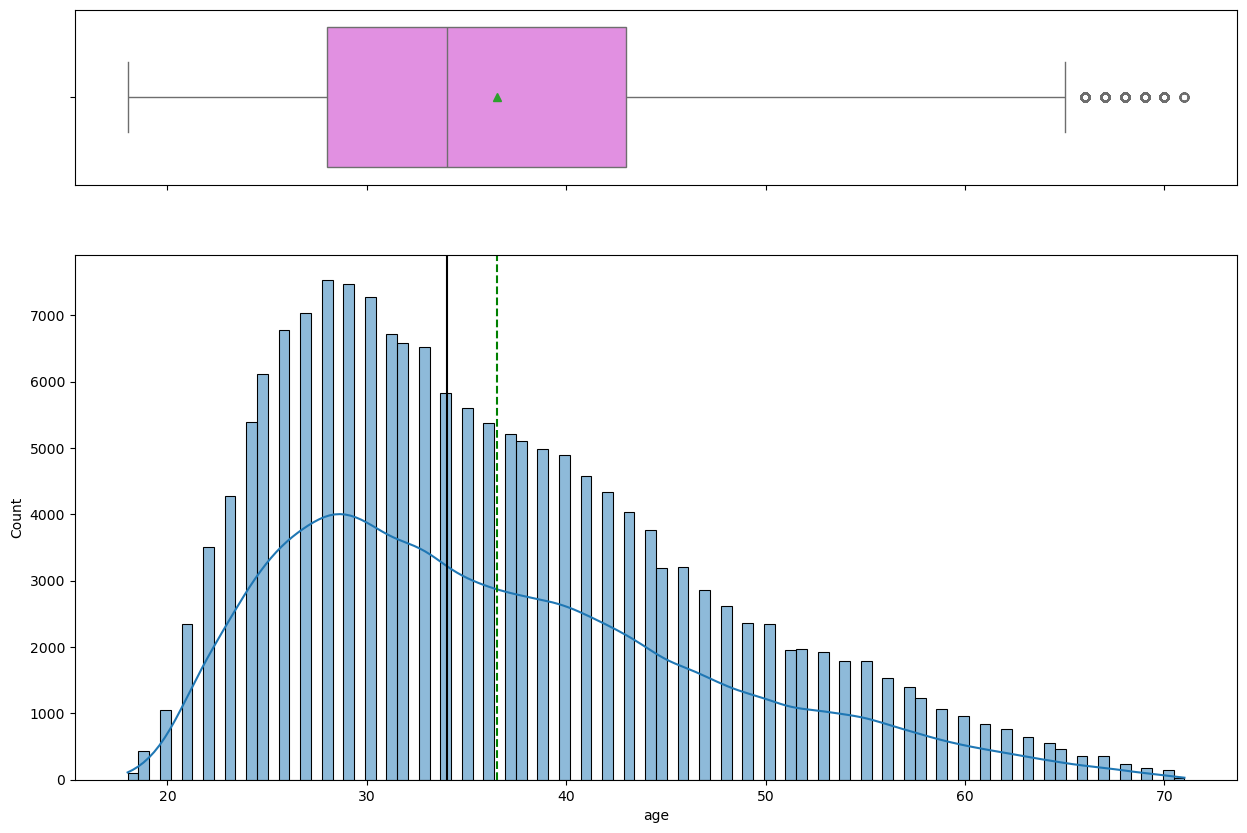

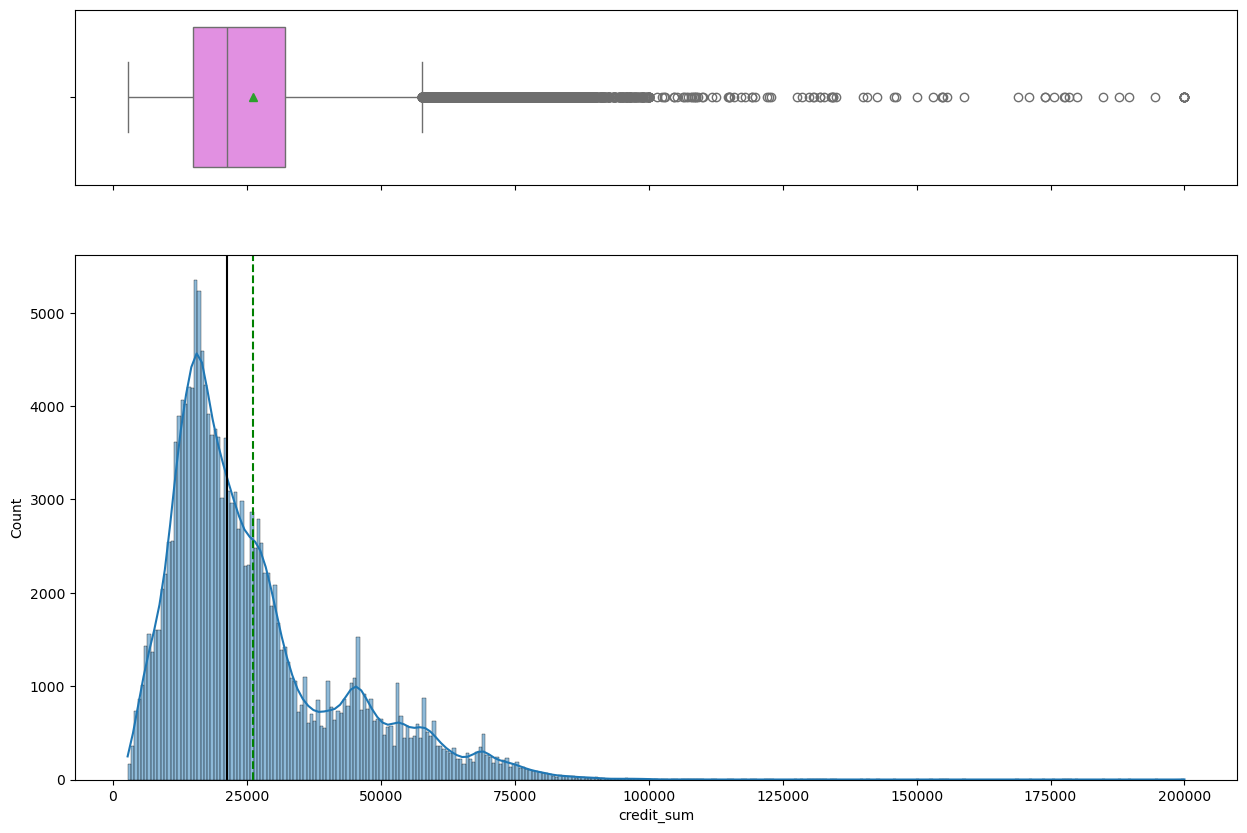

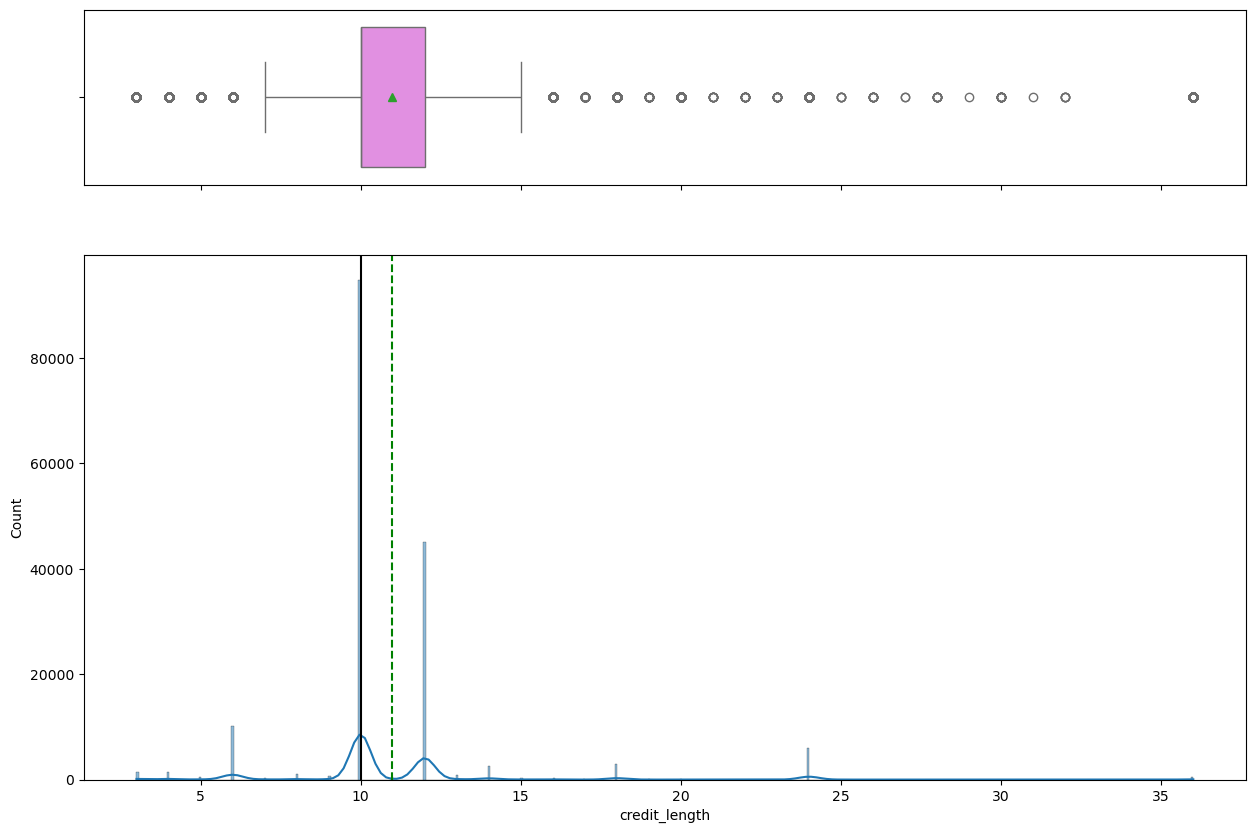

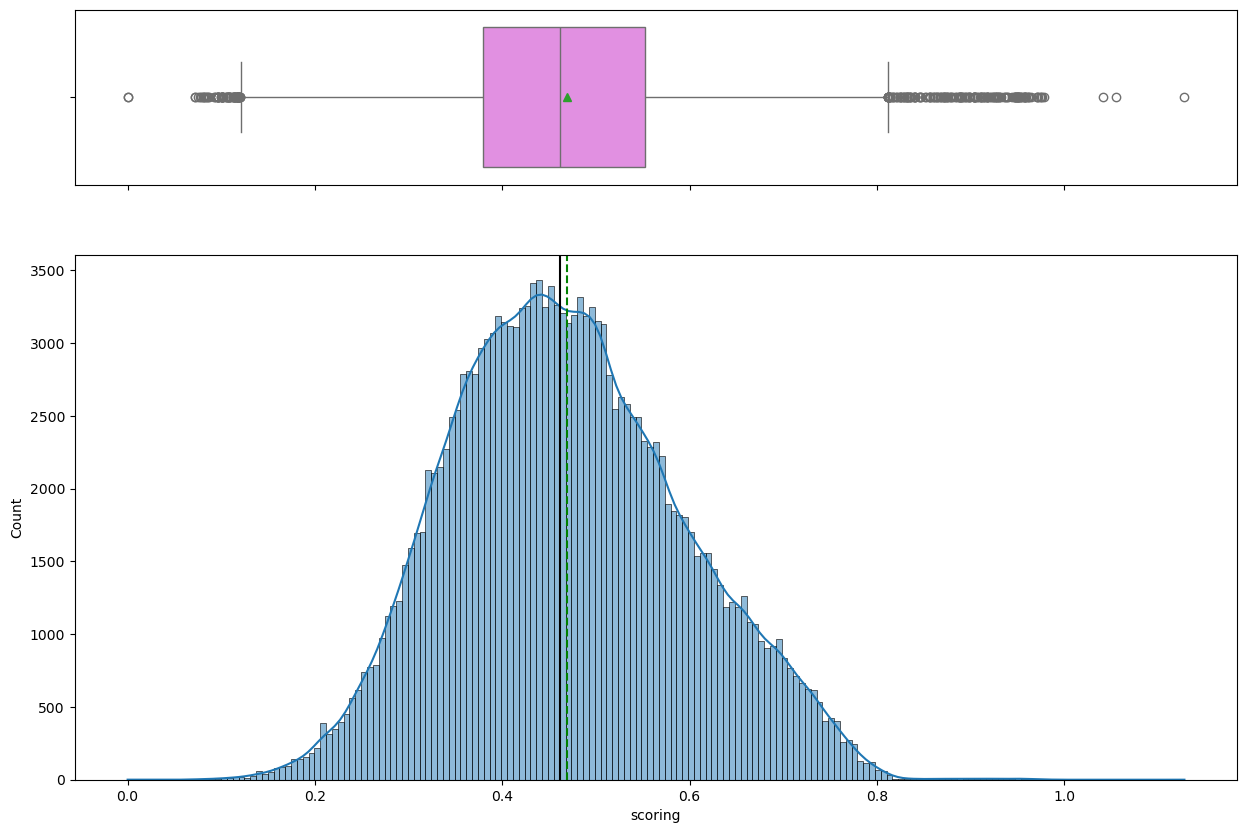

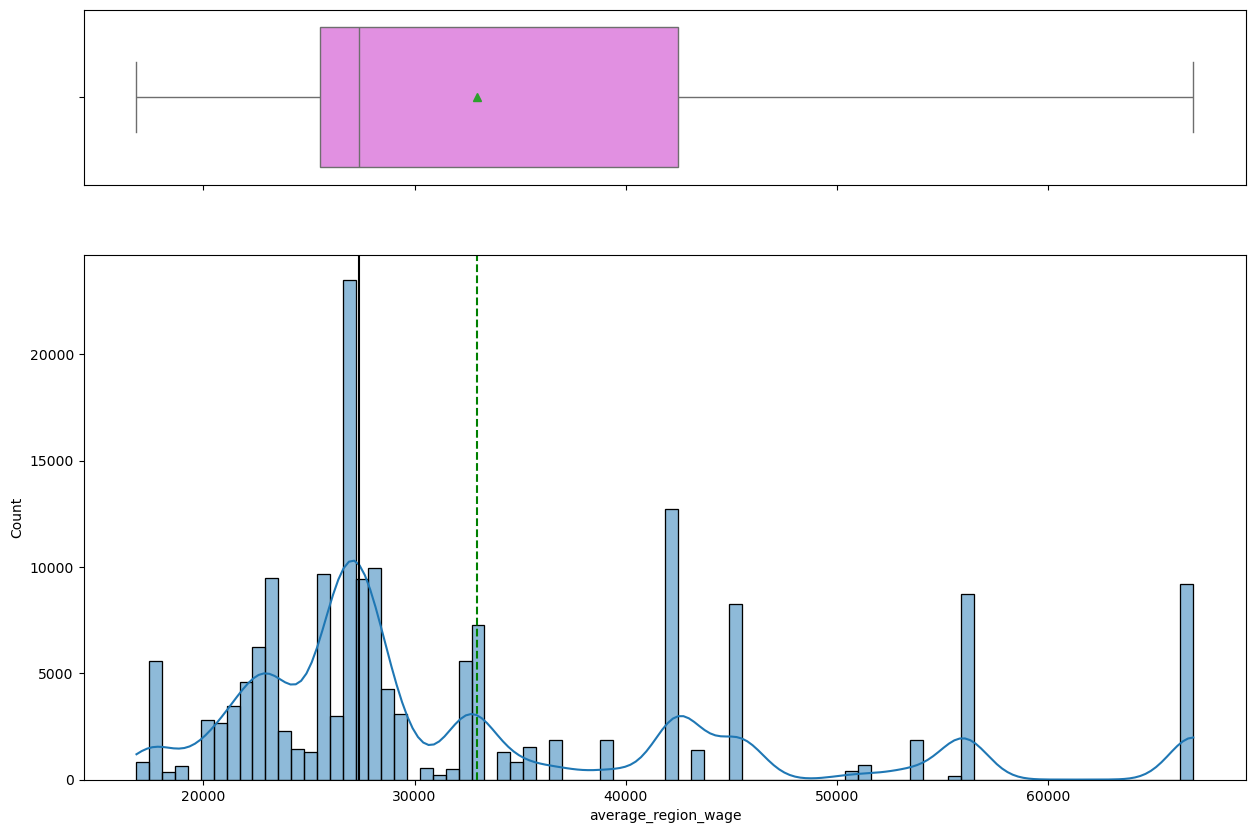

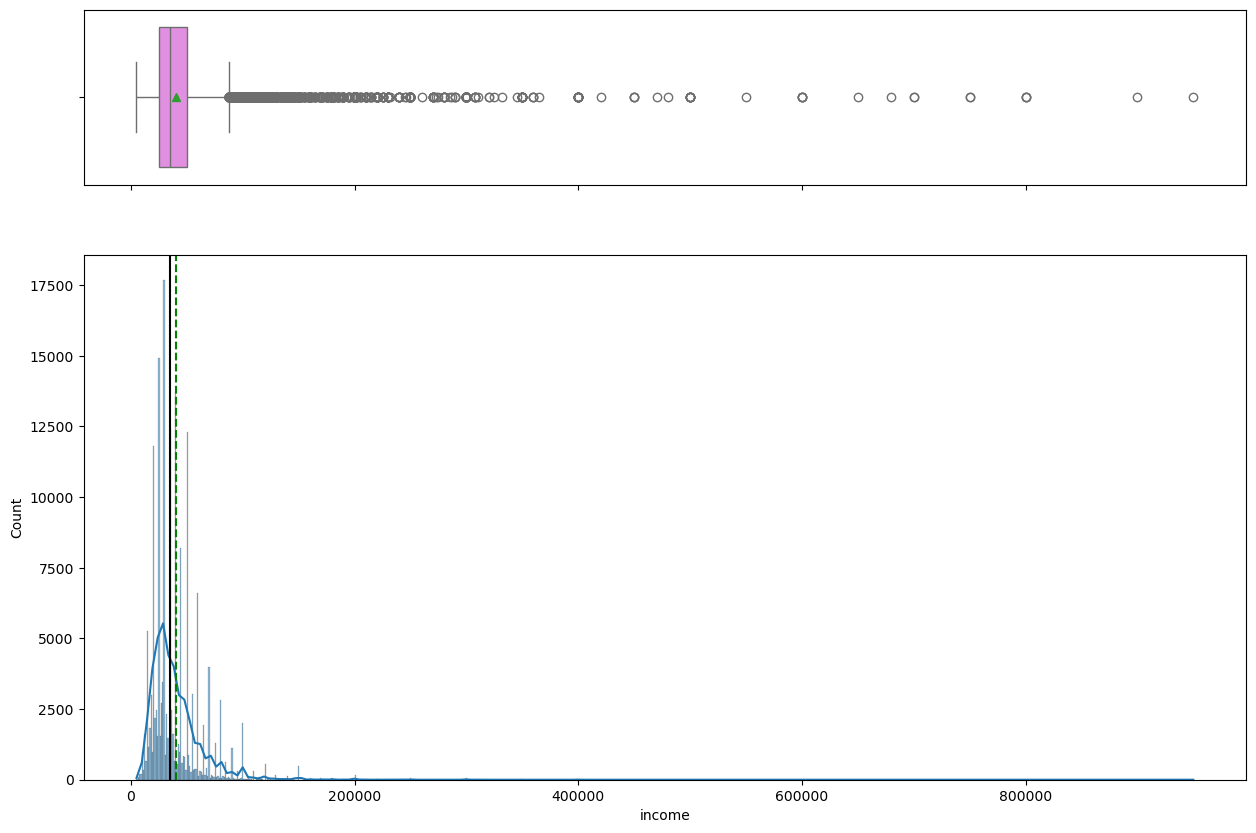

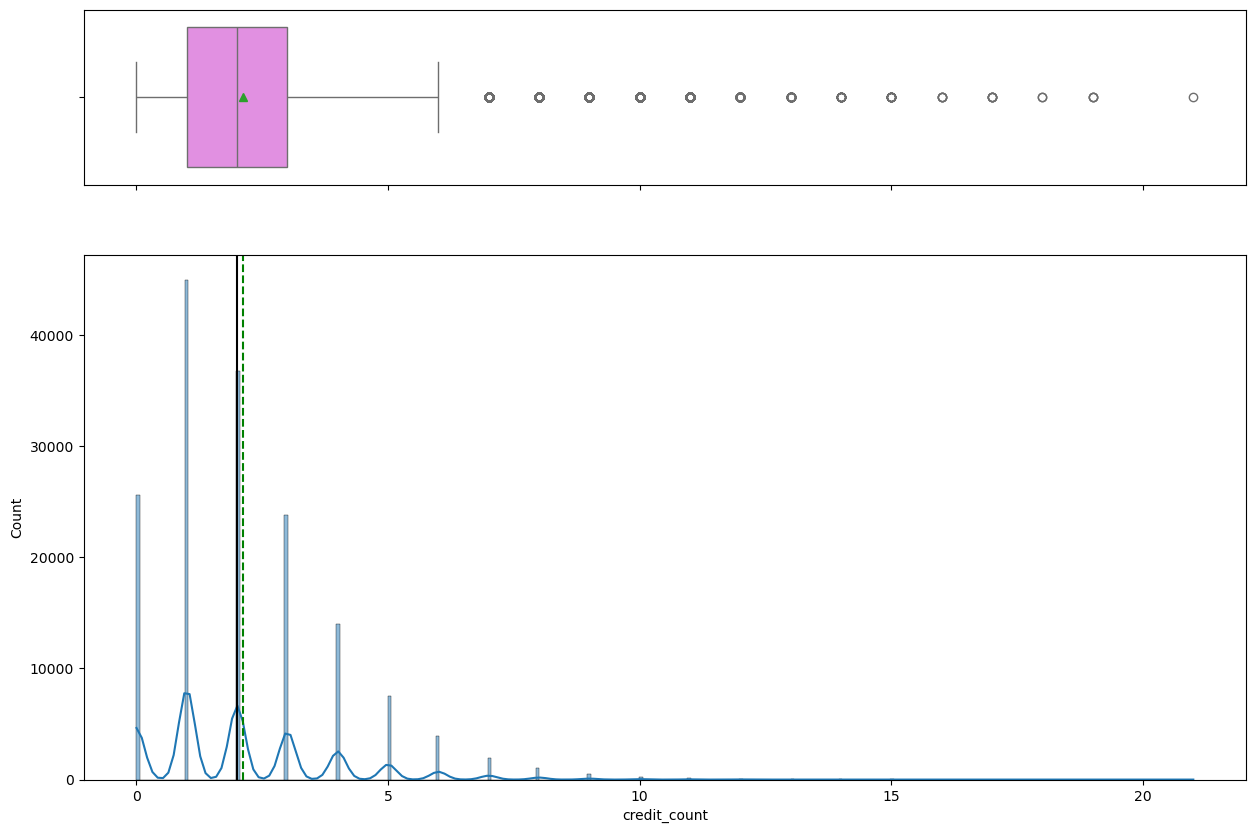

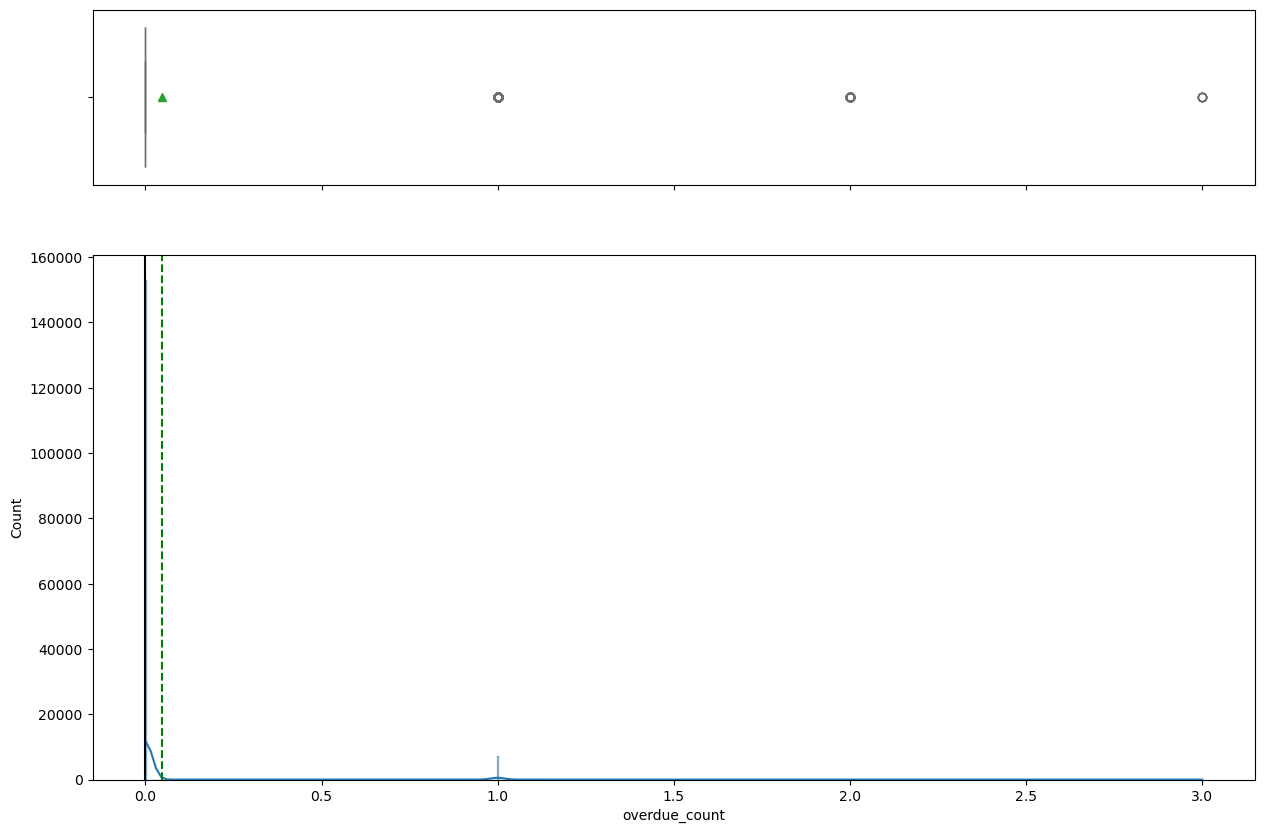

In [22]:
for i in num_columns:
    histogram_boxplot(df, i ,kde = True)

`Age`
-  Right-skewed, a common distritbution in age demographic.

`credit_sum`
- has severe outlier, heavily right-skewed.

`credit_length`
- has significant outlier too.

`scoring`
- Somewhat normally-distributed.

`average_region_wage`
- Has many peaks, possibly due to different region have their own unique distribution.

`income`
- Showing common distribution as expected, heavily skewed to the right.

`credit_count` and `overdue_count` 
- Shows no special behaviour.

We will inspect whether we will treat the outliers we have seen later.

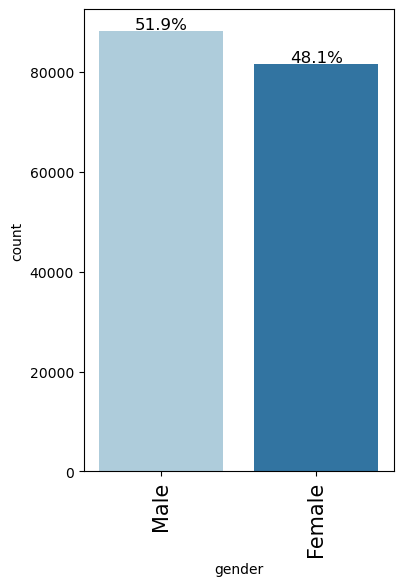

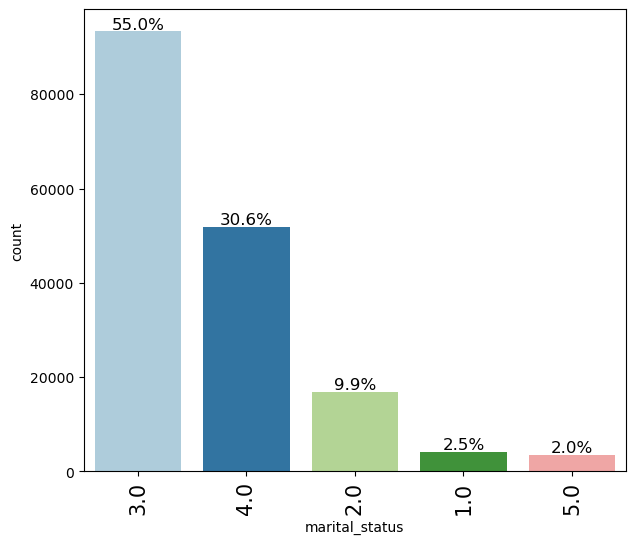

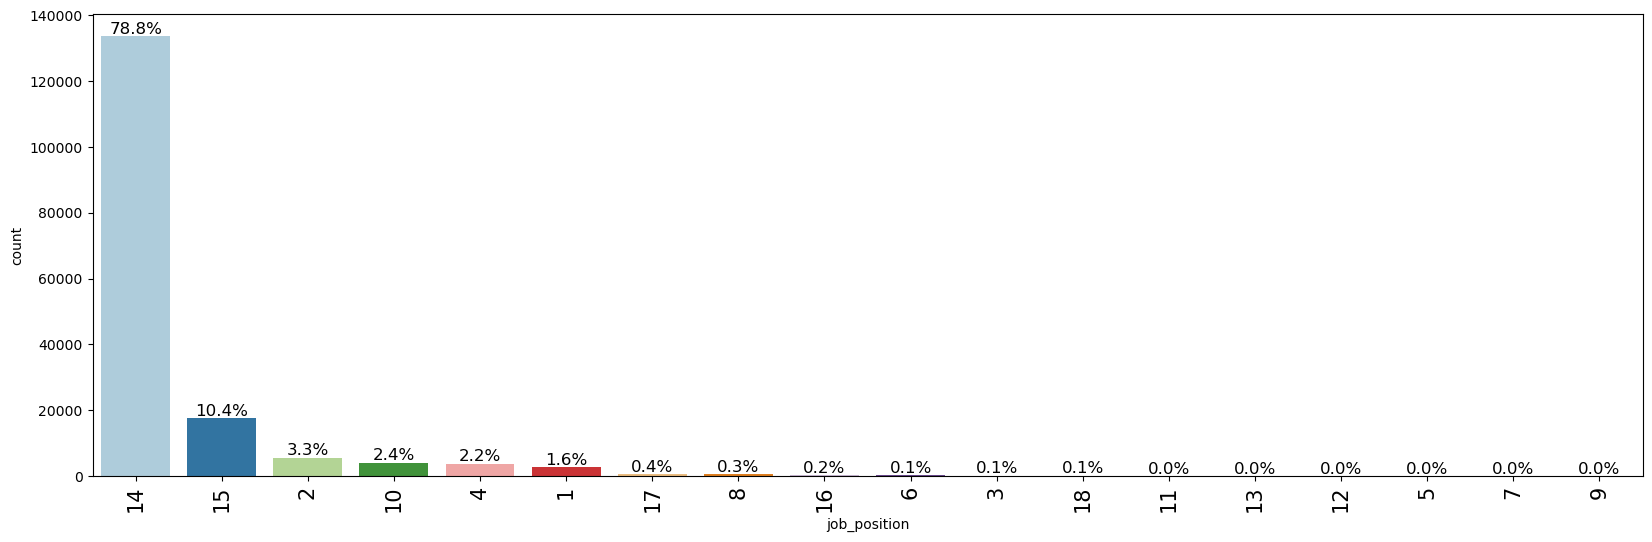

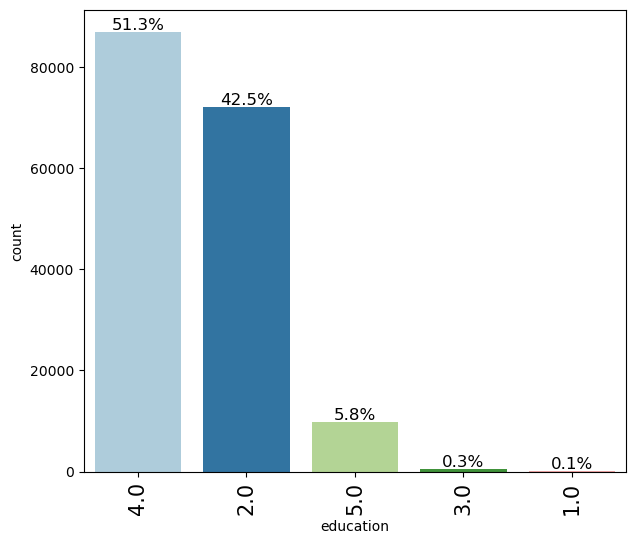

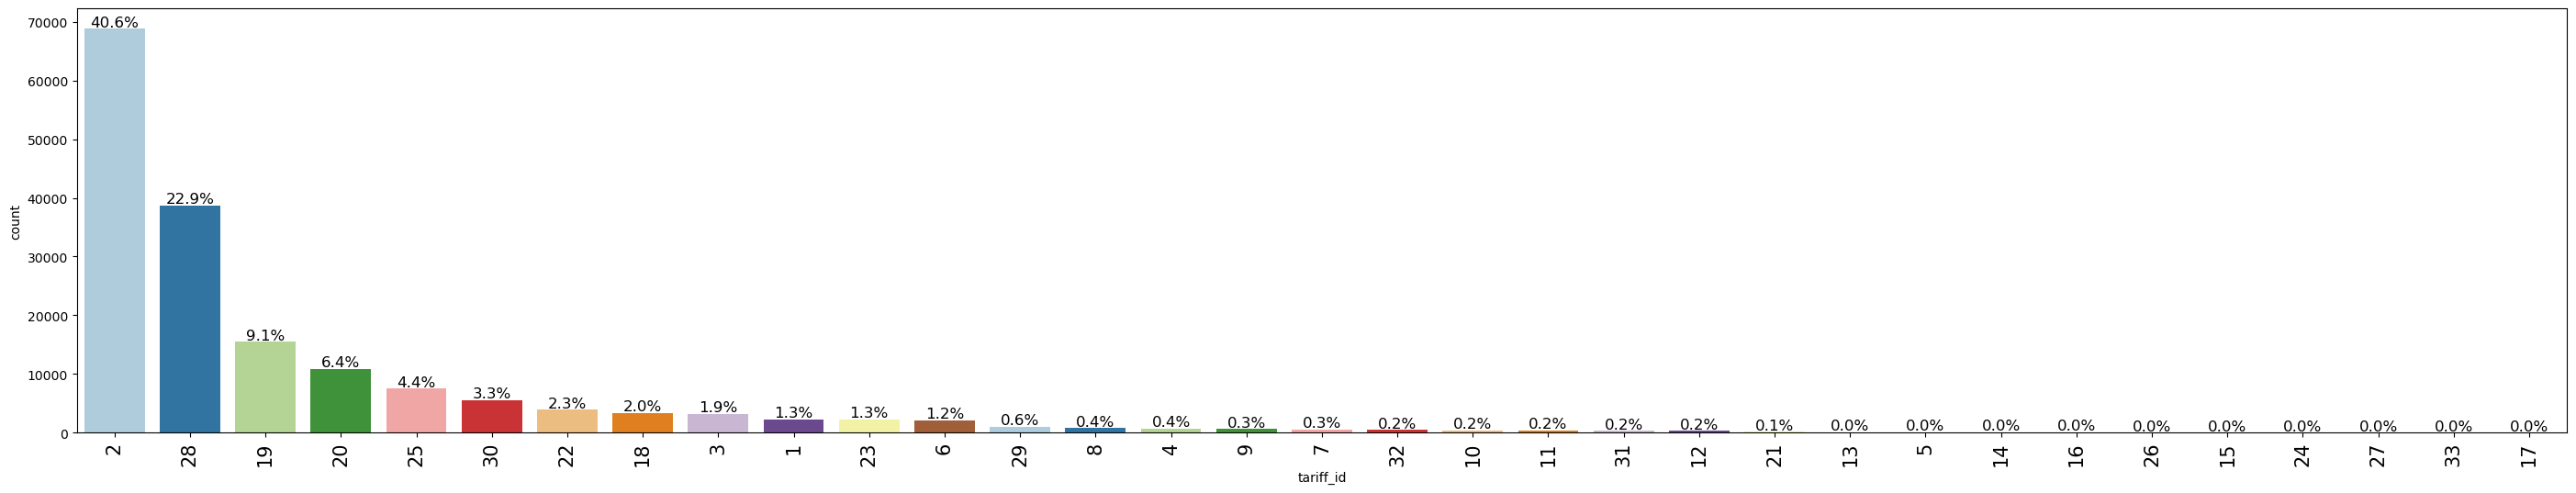

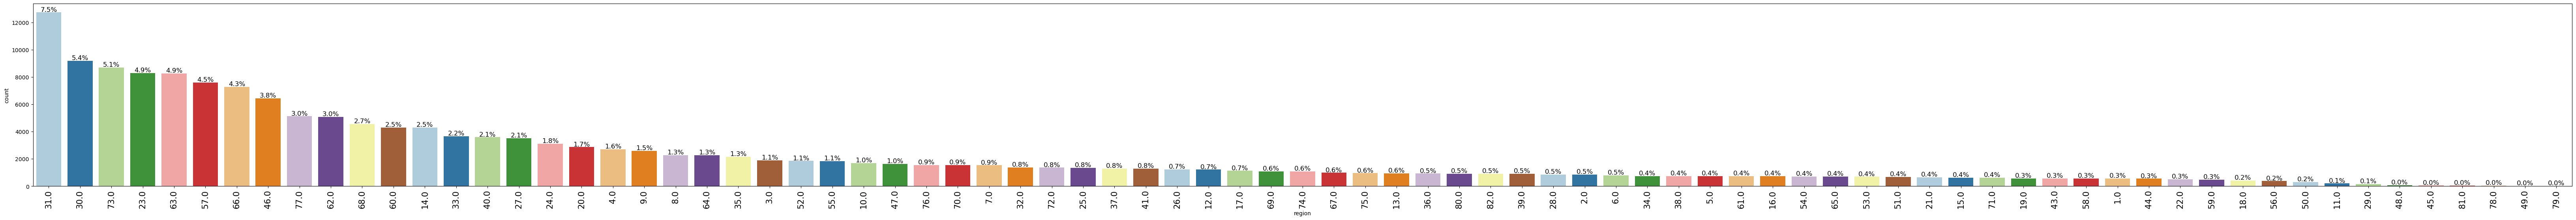

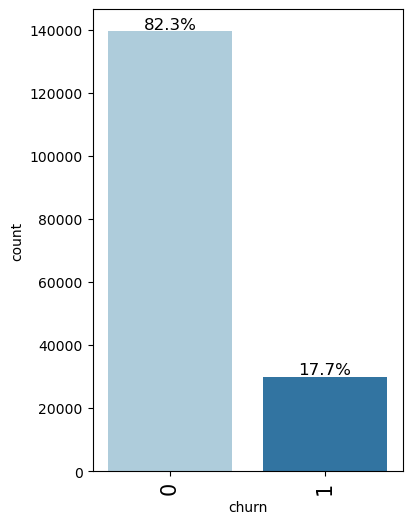

In [23]:
for i in cat_columns:
    labeled_barplot(df, i, perc=True,n=None)

`gender`
- There are more males compare to females, by about 3.8%

`marital_status`
- 55% of the clients are in category 3
- Category 1,2, and 5 are the minorities, totalling 14.4%

`job_position`
- 78.8% of clients are at job category 14.
- Category 1, 2, 4, 10, 15, shows significant amount of clients
- Category 5, 7, 9 has the least.

`education`
- 51.3% of clients are in category 4. Followed by category 2 at 42.5%.
- Category 1, 3, and 5 are rare.

`tariff_id`
- Majority of the clients are under tariff id of category 2 and 28.
- Significant number of clients under category 1, 3, 6, 18, 19, 20, 22, 23, 25.

`region`
- Client's region are not heavily clustered in one. Most popular region is in region 31.

`churn`
- We have imbalance issue, 17.7% clients churned.

### Multivariate

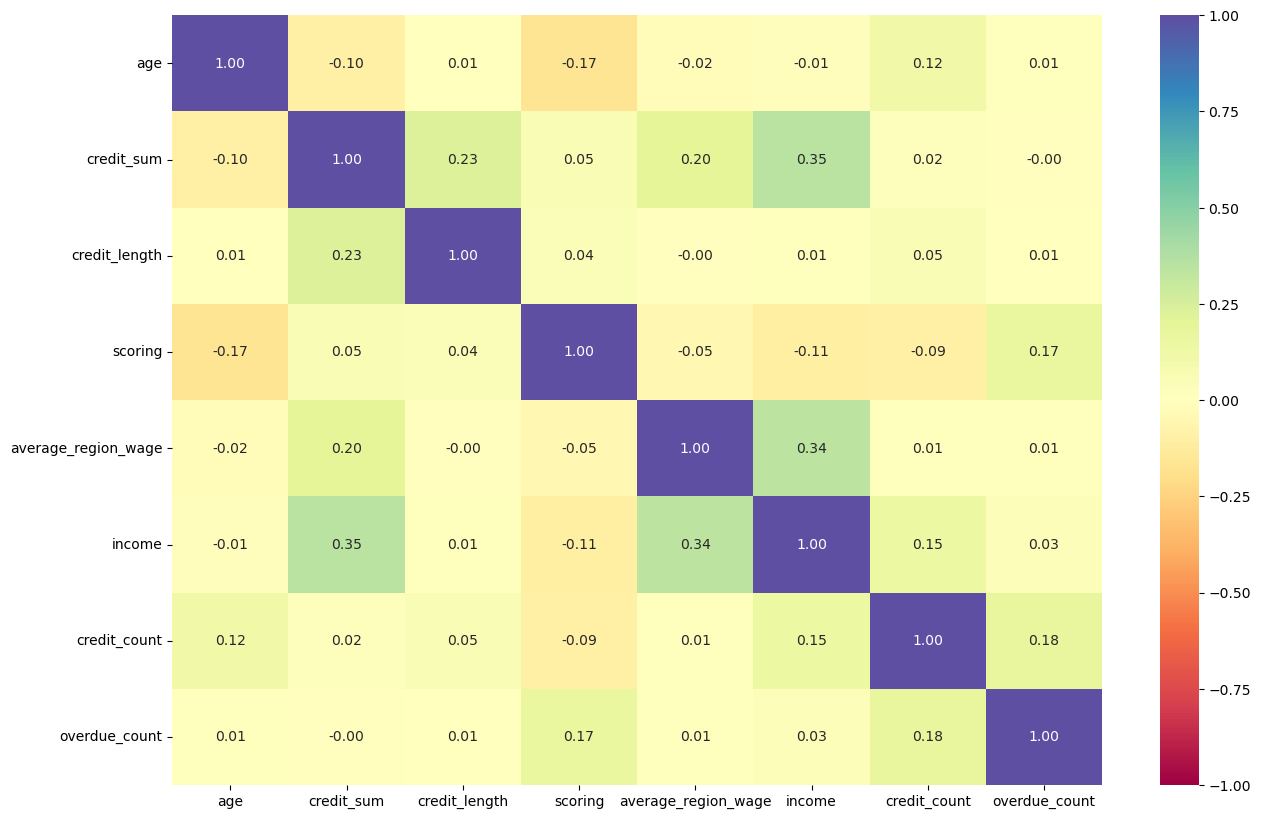

In [24]:
plt.figure(figsize=(15,10))
sns.heatmap(
    df[num_columns].corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral'
)
plt.show()

- No special correlation in between the numerical features, mostly are self explanatory.

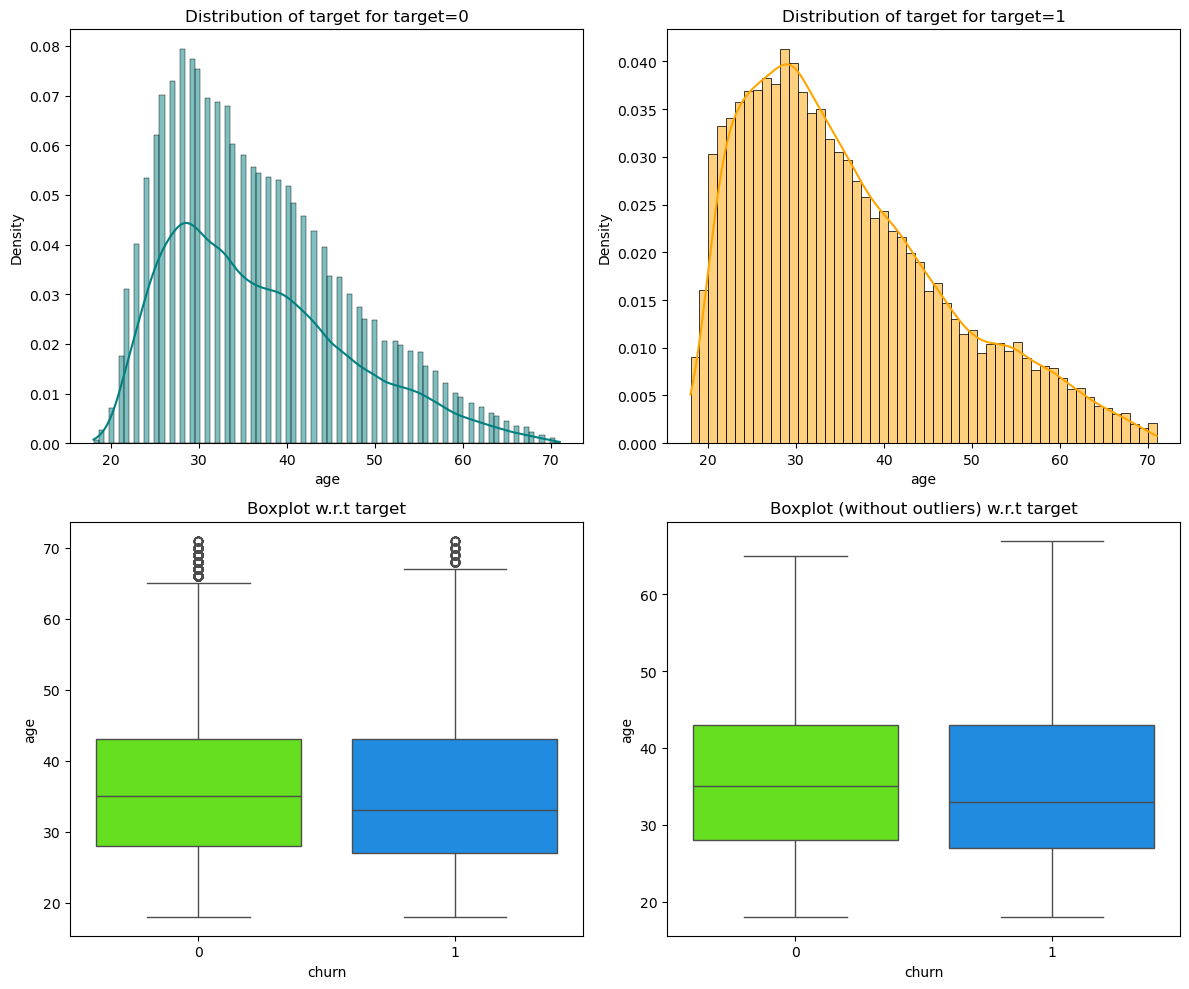

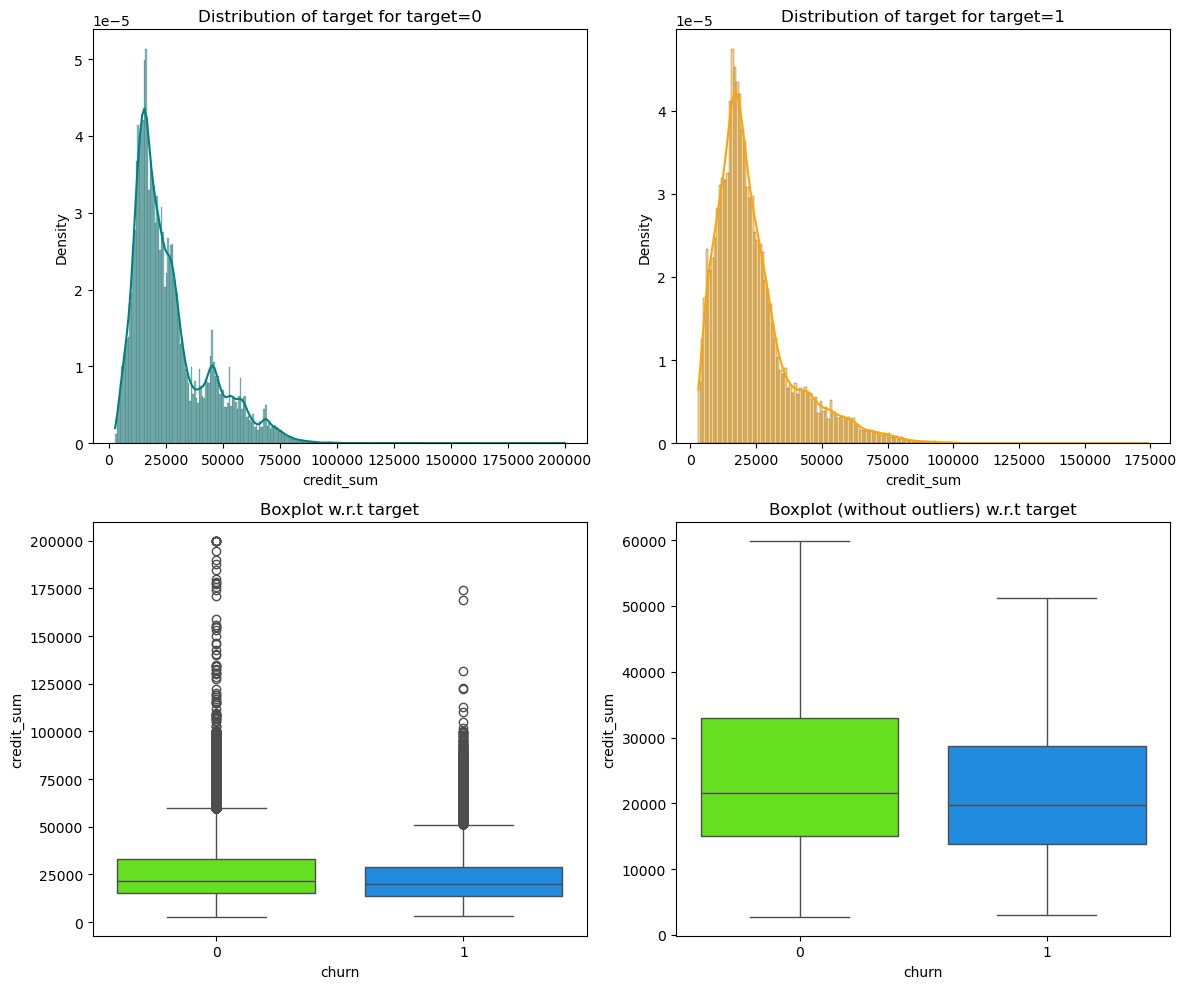

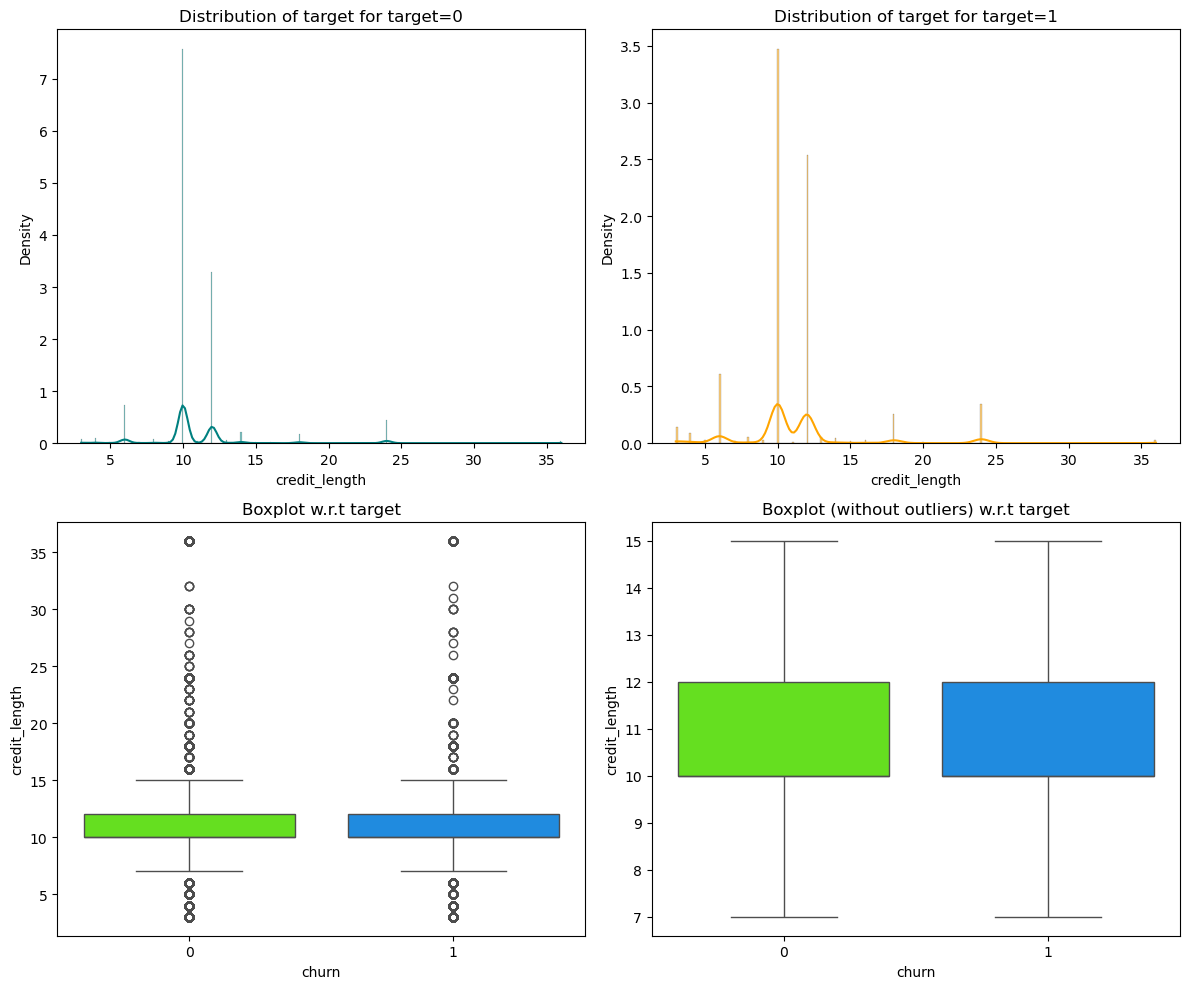

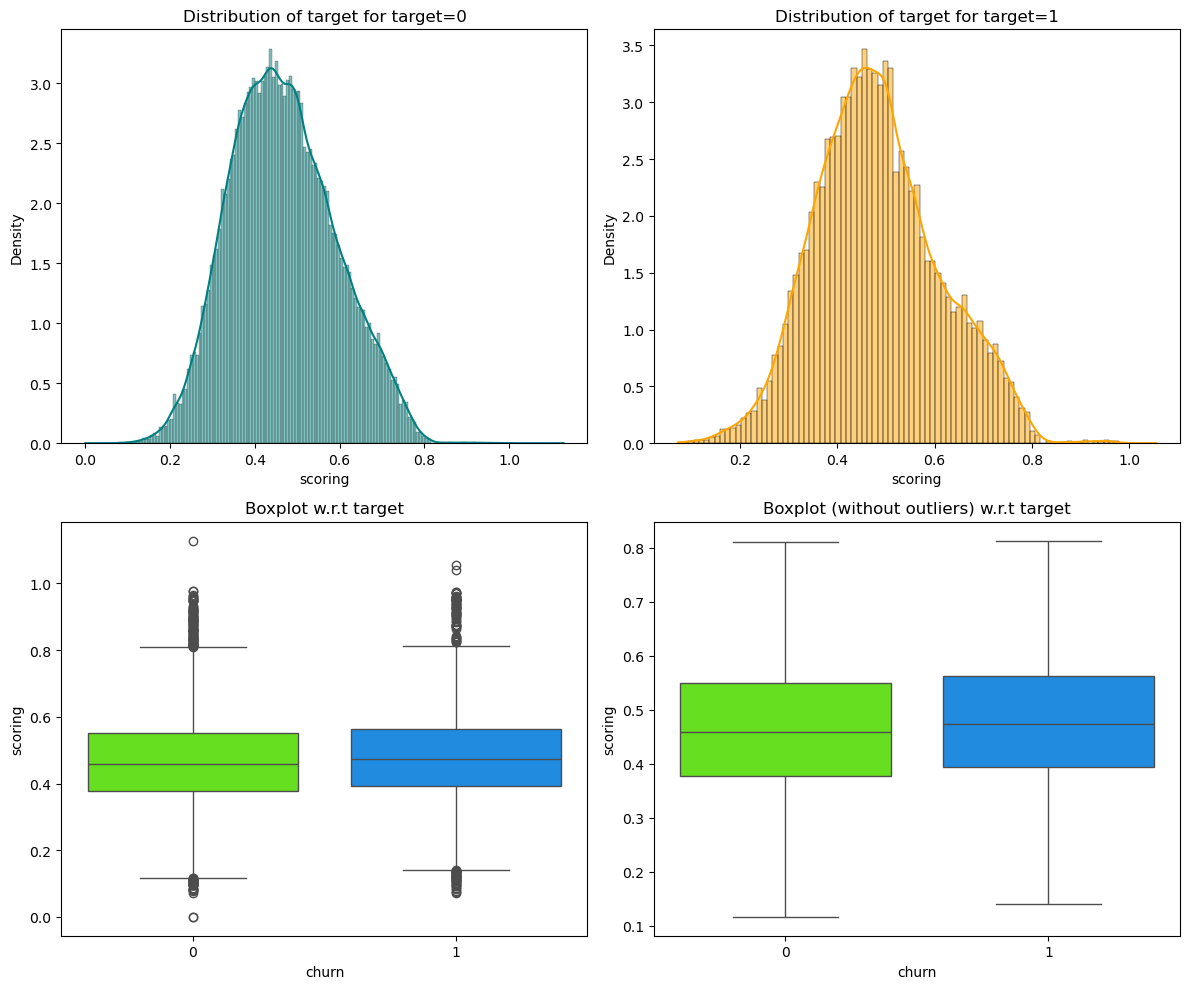

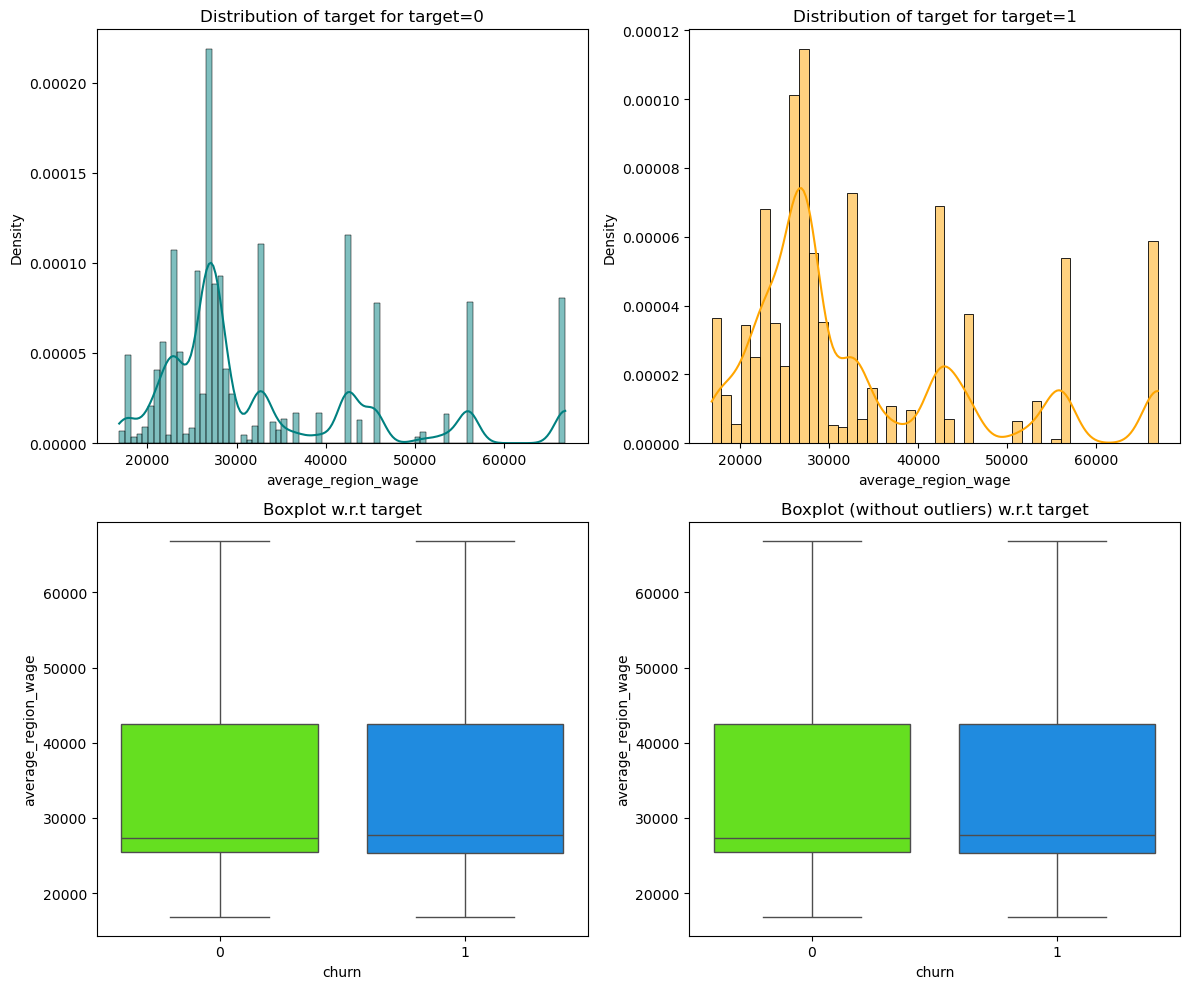

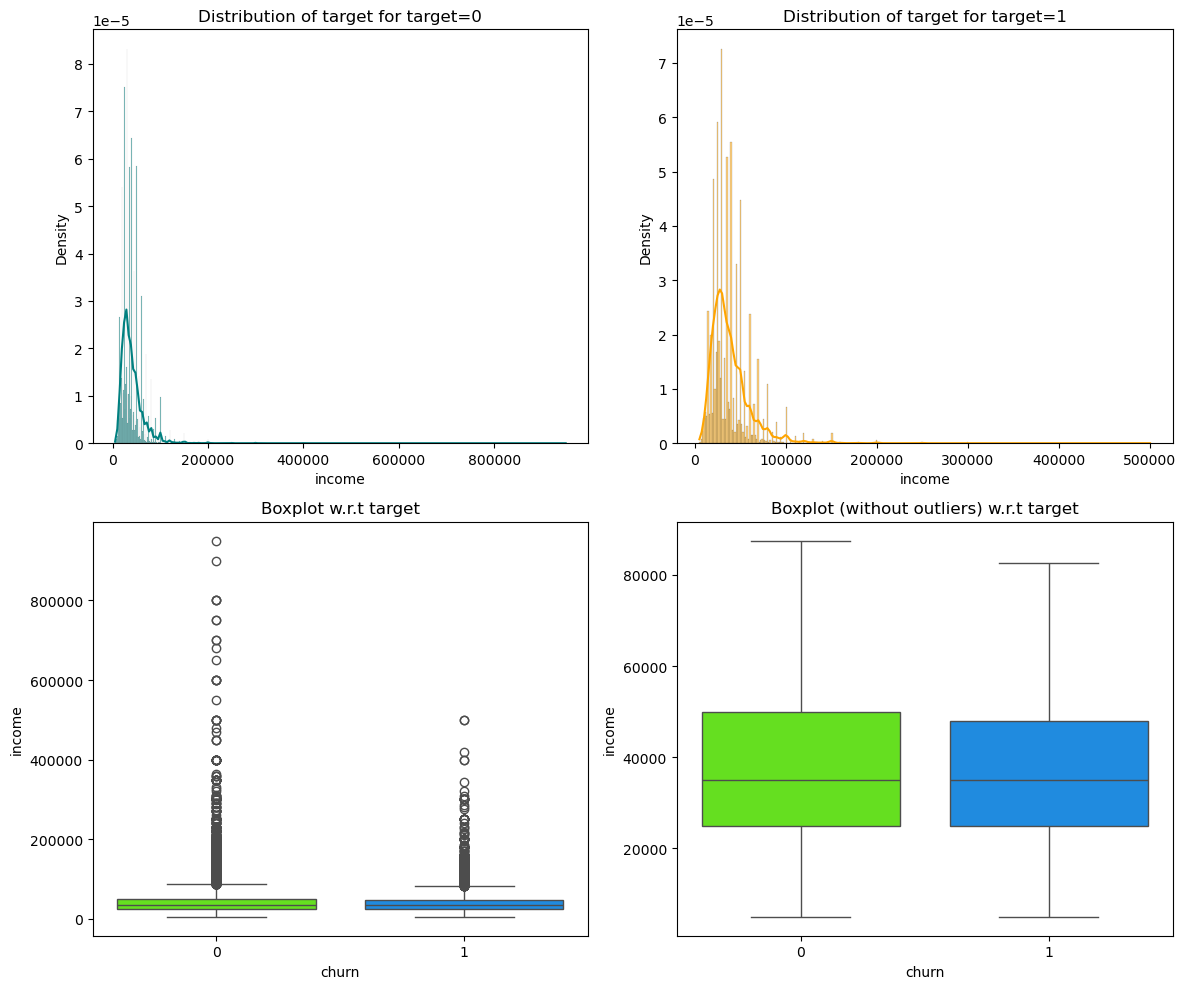

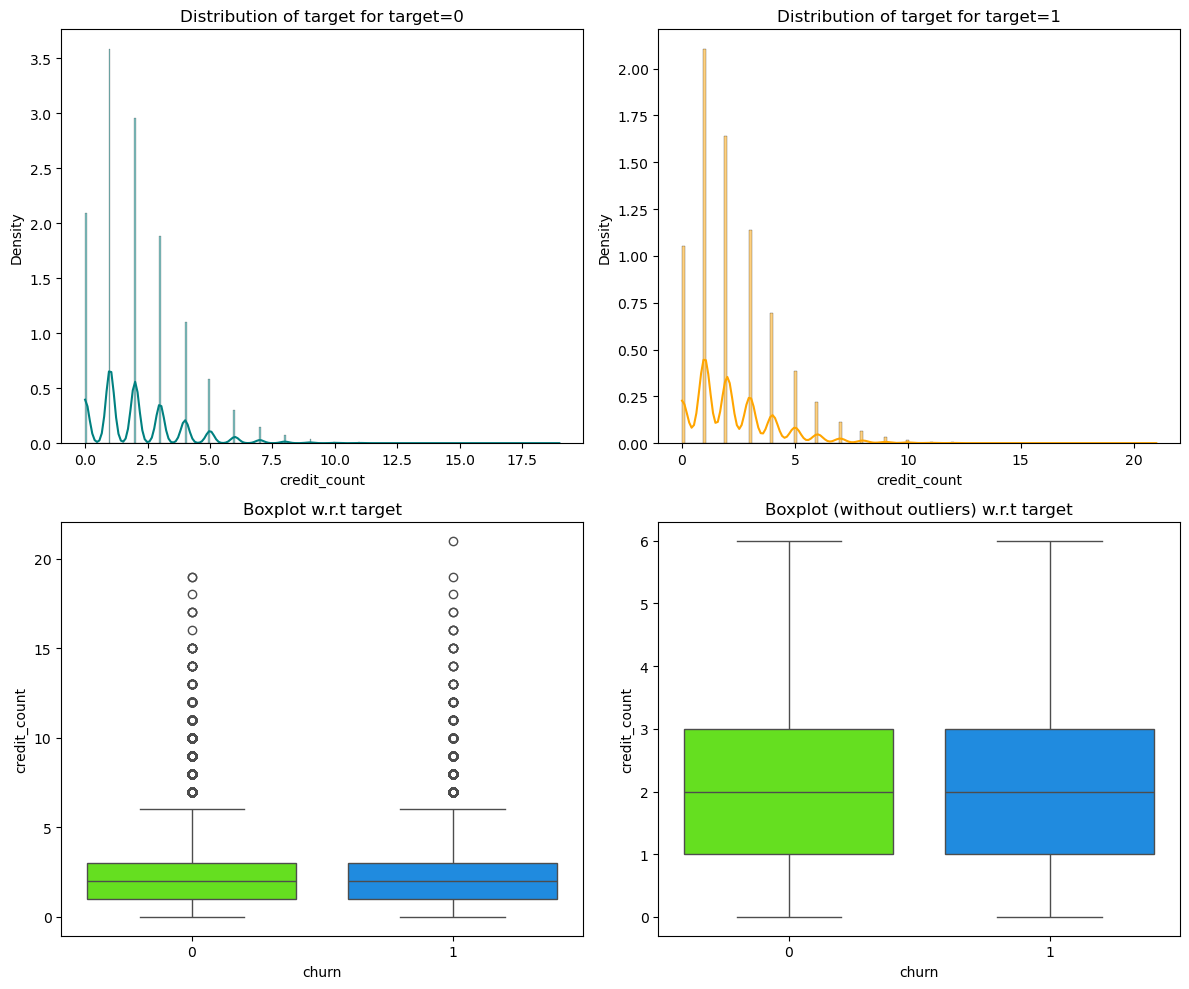

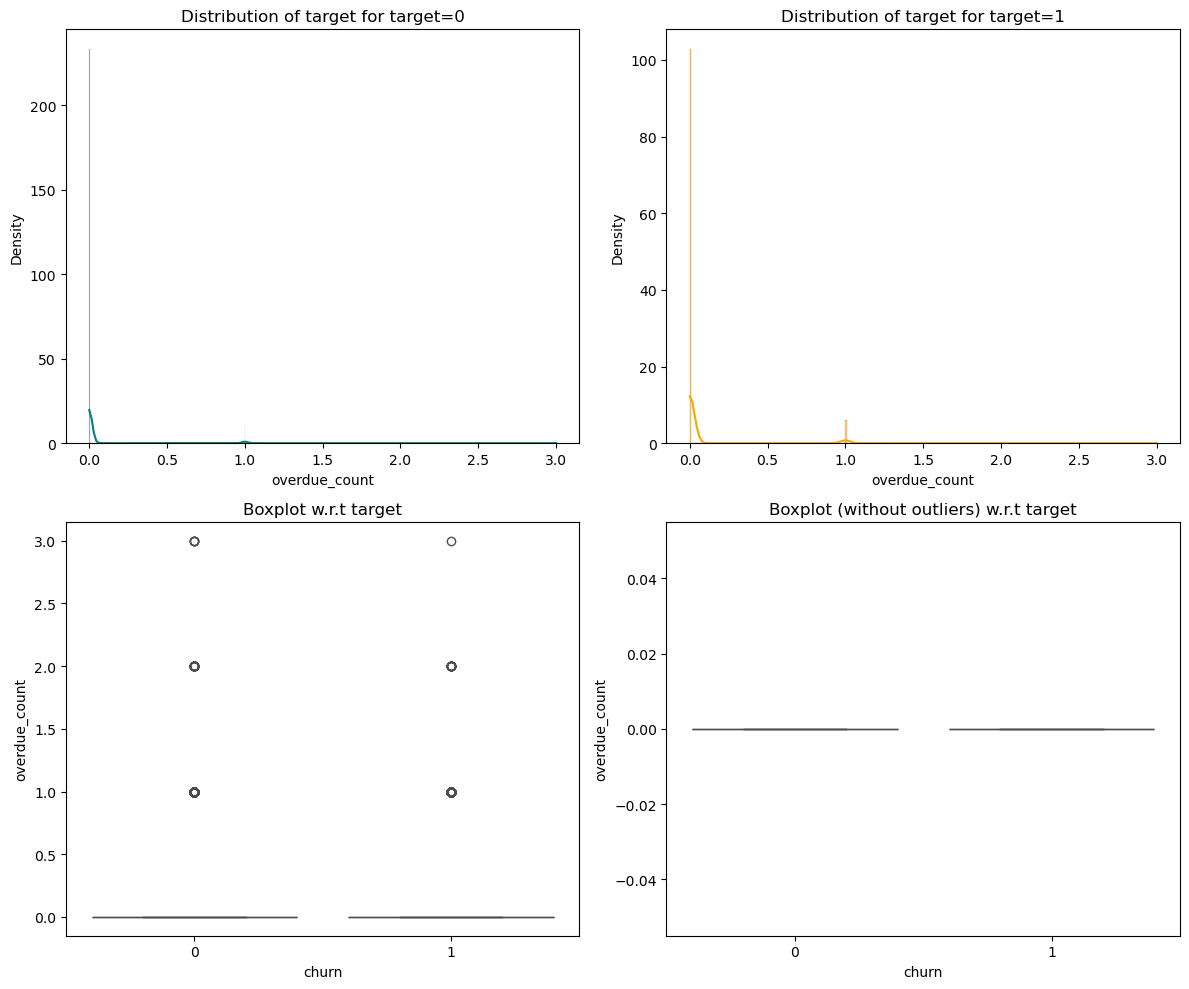

In [25]:
for i in num_columns:
    distribution_plot_wrt_target(df, i, 'churn')

`age`
- Plot shows more younger age clients churned

`credit_sum`
- Clients with lower credit sum churns more.

`credit_length`
- No obvious pattern observed.

`scoring`
- Looks like higher the score the more clients churned.

`average_region_wage`
- No obvious pattern.

`income`
- Lower income churns more.

`credit_count` and `overdue_count`
- Shows no obivous pattern.


churn        0      1     All
gender                       
All     139537  30056  169593
Female   65615  15881   81496
Male     73922  14175   88097
------------------------------------------------------------------------------------------------------------------------


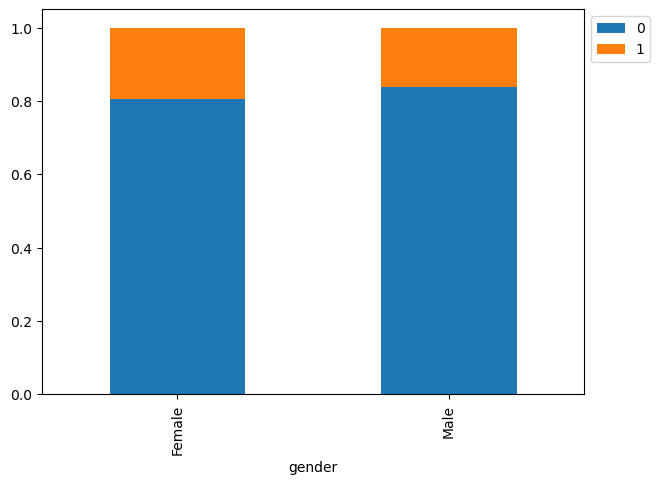

churn                0      1     All
marital_status                       
 All            139532  30056  169588
3.00             78938  14368   93306
4.00             40811  11016   51827
2.00             13746   3090   16836
1.00              3321    846    4167
5.00              2716    736    3452
------------------------------------------------------------------------------------------------------------------------


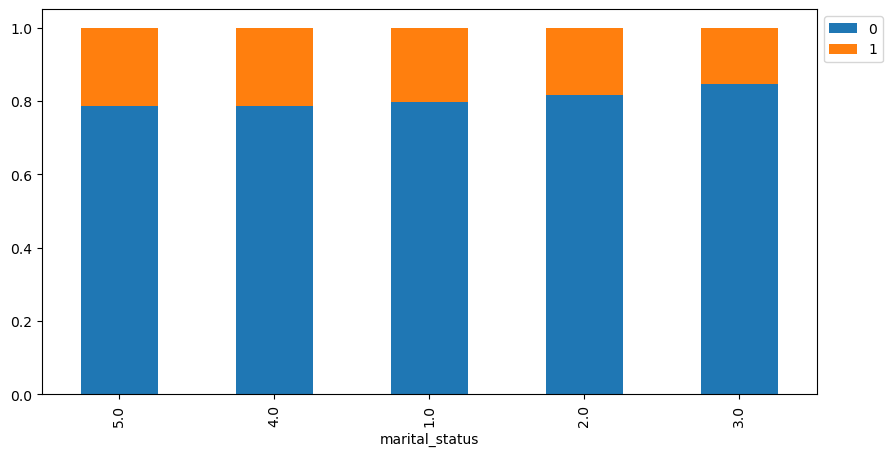

churn              0      1     All
job_position                       
All           139537  30056  169593
14            111308  22403  133711
15             14251   3340   17591
10              2601   1489    4090
2               4664    885    5549
1               1971    807    2778
4               3172    555    3727
8                343    194     537
17               532    121     653
16               267     84     351
6                173     67     240
3                 79     46     125
18                87     23     110
11                45     20      65
13                31      9      40
12                 6      6      12
7                  1      4       5
5                  6      2       8
9                  0      1       1
------------------------------------------------------------------------------------------------------------------------


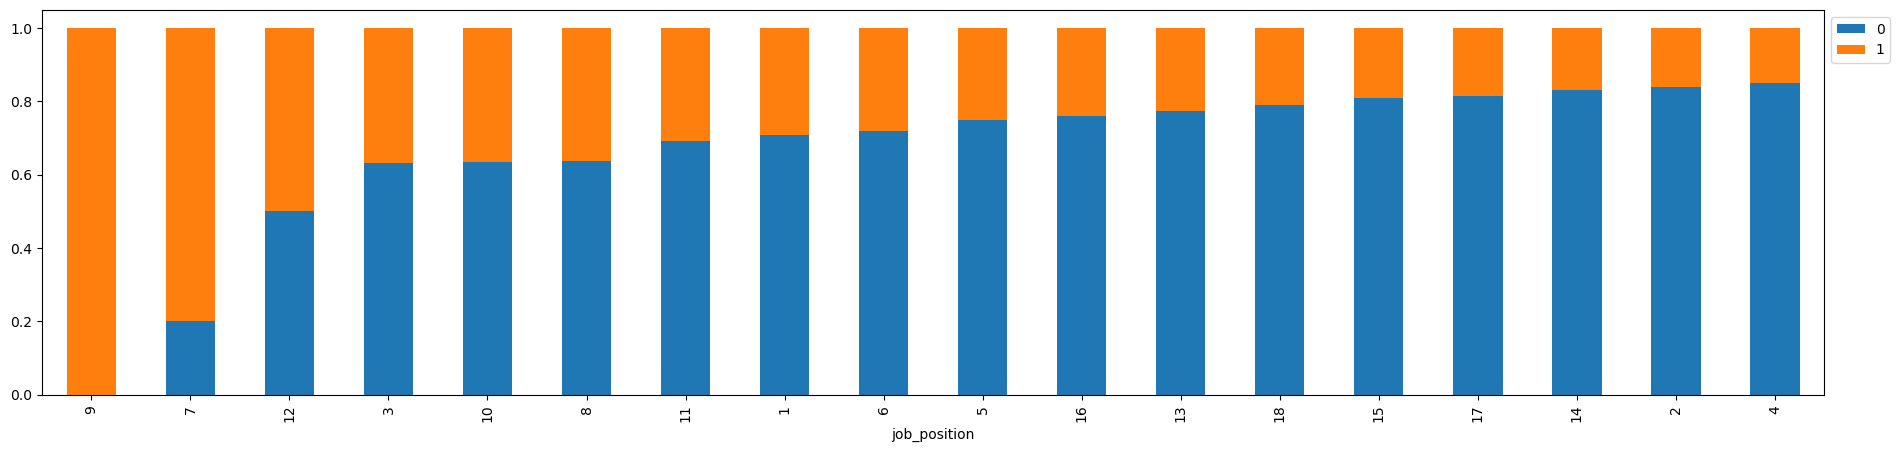

churn           0      1     All
education                       
 All       139535  30055  169590
4.00        69031  17955   86986
2.00        61916  10130   72046
5.00         8053   1837    9890
3.00          453    108     561
1.00           82     25     107
------------------------------------------------------------------------------------------------------------------------


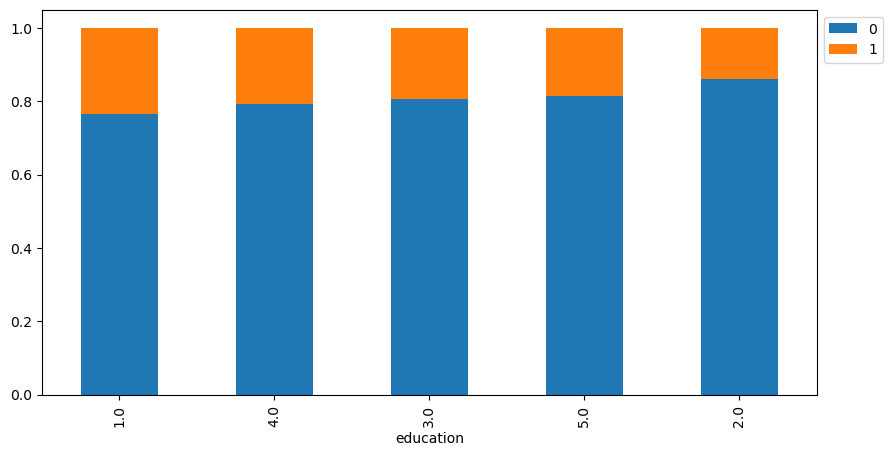

churn           0      1     All
tariff_id                       
All        139537  30056  169593
2           55702  13190   68892
19           9624   5866   15490
28          33249   5515   38764
20           9627   1253   10880
18           2347    992    3339
25           6726    726    7452
22           3422    474    3896
30           5157    369    5526
3            2844    349    3193
23           1935    285    2220
6            1851    235    2086
1            2080    159    2239
4             586    123     709
29            903    102    1005
31            236     78     314
7             473     66     539
8             697     61     758
12            256     47     303
32            368     46     414
5               3     33      36
21            106     26     132
9             558     17     575
11            350     15     365
10            355     14     369
13             41     13      54
17              0      1       1
14             10      1      11
27        

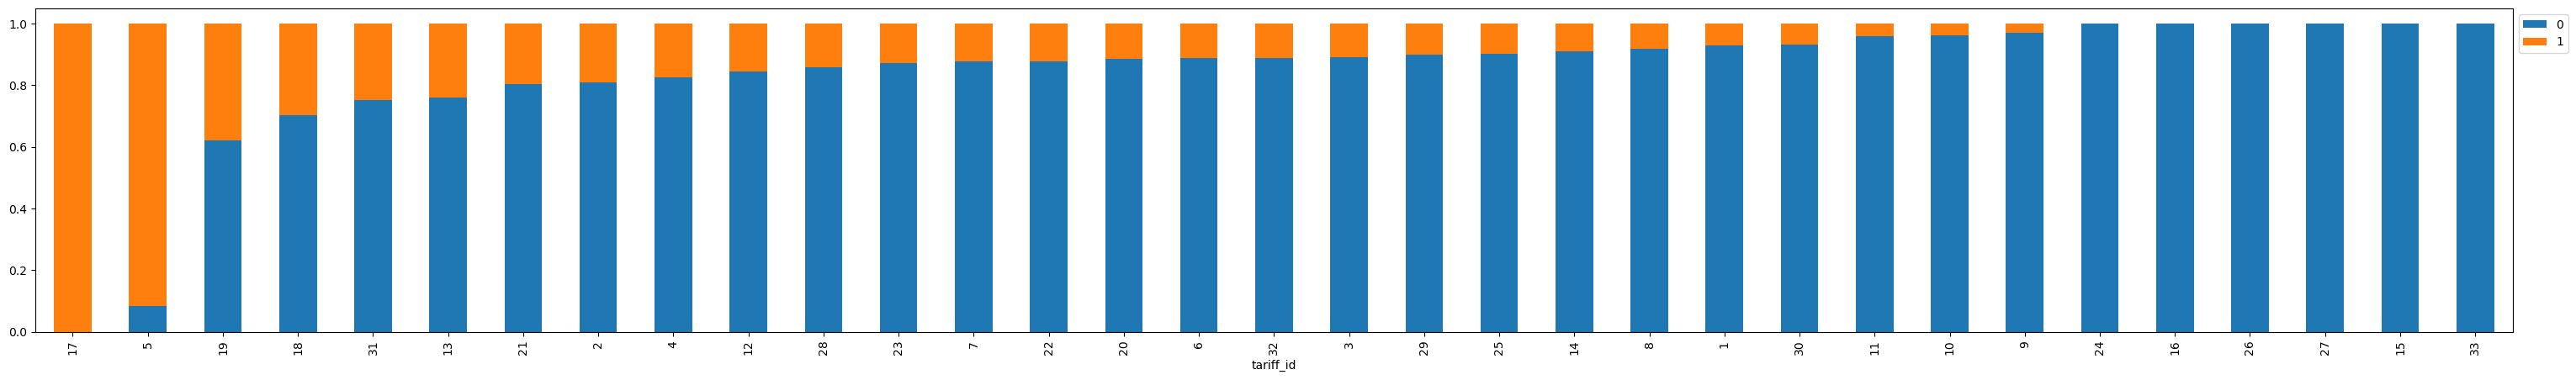

churn        0      1     All
region                       
 All    139348  30056  169404
31.00    10479   2258   12737
30.00     7281   1917    9198
73.00     6952   1736    8688
23.00     6622   1674    8296
63.00     7036   1228    8264
66.00     6084   1193    7277
57.00     6477   1130    7607
77.00     4166    954    5120
14.00     3355    935    4290
46.00     5499    934    6433
60.00     3440    856    4296
33.00     3011    651    3662
24.00     2474    630    3104
62.00     4462    612    5074
20.00     2275    592    2867
40.00     2996    590    3586
27.00     2922    587    3509
68.00     4113    455    4568
8.00      1867    413    2280
35.00     1741    412    2153
64.00     1866    404    2270
55.00     1448    400    1848
3.00      1530    354    1884
76.00     1203    347    1550
70.00     1214    323    1537
4.00      2383    319    2702
52.00     1535    319    1854
12.00      914    302    1216
47.00     1354    285    1639
10.00     1421    281    1702
7.00      

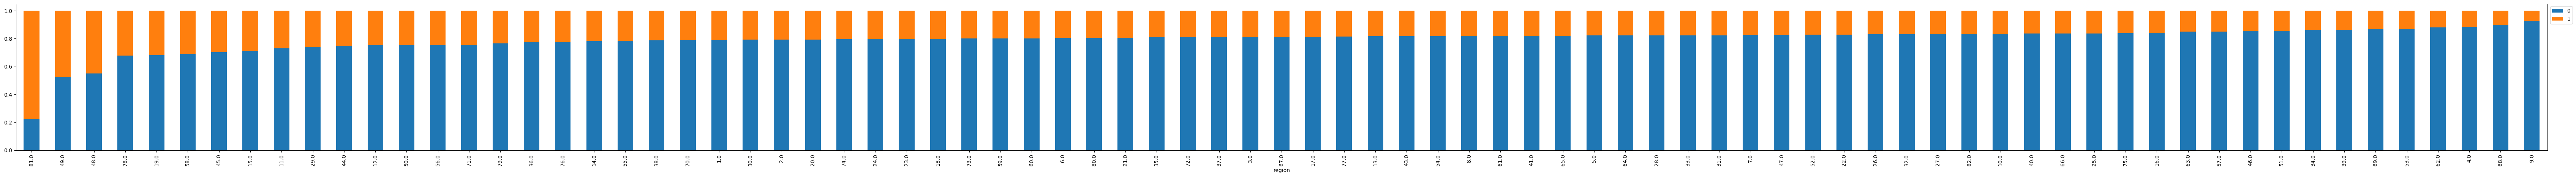

churn       0      1     All
churn                       
1           0  30056   30056
All    139537  30056  169593
0      139537      0  139537
------------------------------------------------------------------------------------------------------------------------


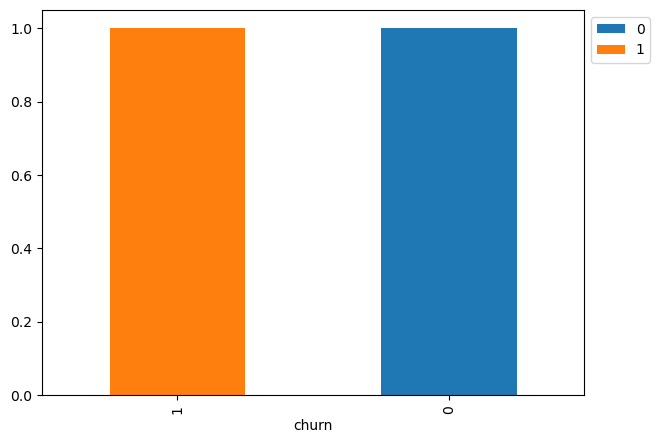

In [26]:
for i in cat_columns:
    stacked_barplot(df, i, 'churn')

`gender`
- Females churns more than male

`marital_status`
- Category 4 shows very high churn rate, comparable to category 5.
- Category 3, where majority is, shows the least churn rate.

`job_position`
- Category 4 shows the least churn rate. Followed by category 2.
- Category 14, where majority is at, has the 3rd least churn rate.
- Category 10 has very high churn rate.

`education`
- Category 2 has the least churn.
- Category 1 has highest churn rate.
- Category 4, where majority is, is the 2nd highest in churn rate.

`tariff_id`
- ID 1, 3, 8, 9, 10, 11, 25, 29, 30 has very low churn rate.
- ID 5 has very high churn rate.
- ID 18, 19 are significantly high in churning.

`region`
- Region 48, 49, 81 has significant churn rate.
- Region 4, 9 , 68 has the least churn rate.

## Data Preprocessing

### Synthesize unique ID

In [27]:
df = df.reset_index(drop=True)
df['unique_id'] = df.index

In [28]:
df.head()

,gender,age,marital_status,job_position,credit_sum,credit_length,scoring,education,tariff_id,region,average_region_wage,income,credit_count,overdue_count,churn,unique_id
0,Female,48,3.00,15,59998.00,10,0.77,2.00,28,23.00,25850.00,30000.00,1.00,1.00,0,0
1,Male,28,NaN,15,10889.00,6,0.25,2.00,2,30.00,66880.00,43000.00,2.00,0.00,0,1
2,Female,32,3.00,14,10728.00,12,0.46,4.00,2,64.00,23430.00,23000.00,5.00,0.00,0,2
3,Male,27,2.00,14,12009.09,12,0.36,2.00,2,8.00,23650.00,17000.00,2.00,0.00,0,3
4,Female,45,3.00,14,16908.89,10,0.42,4.00,2,77.00,26620.00,NaN,1.00,0.00,0,4


### Outlier treatment

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,169593.00,36.50,10.55,18.00,28.00,34.00,43.00,71.00
credit_sum,169592.00,26077.63,16227.07,2736.00,14907.95,21220.00,32028.00,200000.00
credit_length,169593.00,10.98,3.54,3.00,10.00,10.00,12.00,36.00
scoring,169590.00,0.47,0.12,0.00,0.38,0.46,0.55,1.13
average_region_wage,169404.00,32962.28,12578.22,16830.00,25520.00,27390.00,42460.00,66880.00
income,169591.00,40125.19,25026.37,5000.00,25000.00,35000.00,50000.00,950000.00
credit_count,160403.00,2.11,1.78,0.00,1.00,2.00,3.00,21.00
overdue_count,160403.00,0.05,0.21,0.00,0.00,0.00,0.00,3.00
unique_id,169593.00,84796.00,48957.43,0.00,42398.00,84796.00,127194.00,169592.00


In [30]:
print(df[df['scoring'] > 1.0].shape[0])
print(df[df['income'] > 200000].shape[0])

3
267


In [31]:
df = df[df['scoring'] <= 1.0]

In [32]:
df['income'] = df['income'].clip(upper=200000)

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,169587.00,36.50,10.55,18.00,28.00,34.00,43.00,71.00
credit_sum,169586.00,26077.56,16227.17,2736.00,14907.95,21220.00,32026.50,200000.00
credit_length,169587.00,10.98,3.54,3.00,10.00,10.00,12.00,36.00
scoring,169587.00,0.47,0.12,0.00,0.38,0.46,0.55,0.98
average_region_wage,169398.00,32962.12,12578.25,16830.00,25520.00,27390.00,42460.00,66880.00
income,169585.00,39944.74,22890.74,5000.00,25000.00,35000.00,50000.00,200000.00
credit_count,160400.00,2.11,1.78,0.00,1.00,2.00,3.00,21.00
overdue_count,160400.00,0.05,0.21,0.00,0.00,0.00,0.00,3.00
unique_id,169587.00,84797.83,48956.54,0.00,42400.50,84798.00,127194.50,169592.00


### Feature Engineering

In [34]:
df.head()

,gender,age,marital_status,job_position,credit_sum,credit_length,scoring,education,tariff_id,region,average_region_wage,income,credit_count,overdue_count,churn,unique_id
0,Female,48,3.00,15,59998.00,10,0.77,2.00,28,23.00,25850.00,30000.00,1.00,1.00,0,0
1,Male,28,NaN,15,10889.00,6,0.25,2.00,2,30.00,66880.00,43000.00,2.00,0.00,0,1
2,Female,32,3.00,14,10728.00,12,0.46,4.00,2,64.00,23430.00,23000.00,5.00,0.00,0,2
3,Male,27,2.00,14,12009.09,12,0.36,2.00,2,8.00,23650.00,17000.00,2.00,0.00,0,3
4,Female,45,3.00,14,16908.89,10,0.42,4.00,2,77.00,26620.00,NaN,1.00,0.00,0,4


In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,169587.00,36.50,10.55,18.00,28.00,34.00,43.00,71.00
credit_sum,169586.00,26077.56,16227.17,2736.00,14907.95,21220.00,32026.50,200000.00
credit_length,169587.00,10.98,3.54,3.00,10.00,10.00,12.00,36.00
scoring,169587.00,0.47,0.12,0.00,0.38,0.46,0.55,0.98
average_region_wage,169398.00,32962.12,12578.25,16830.00,25520.00,27390.00,42460.00,66880.00
income,169585.00,39944.74,22890.74,5000.00,25000.00,35000.00,50000.00,200000.00
credit_count,160400.00,2.11,1.78,0.00,1.00,2.00,3.00,21.00
overdue_count,160400.00,0.05,0.21,0.00,0.00,0.00,0.00,3.00
unique_id,169587.00,84797.83,48956.54,0.00,42400.50,84798.00,127194.50,169592.00


In [36]:
df['debt_to_income'] = df['credit_sum'] / (df['income'] + 1 )

In [37]:
df.groupby('churn')['debt_to_income'].mean()

churn
0   0.76
1   0.70
Name: debt_to_income, dtype: float64

In [38]:
df['income_vs_region'] = df['income'] / (df['average_region_wage'] + 1)

In [39]:
df.groupby('churn')['income_vs_region'].mean()

churn
0   1.29
1   1.23
Name: income_vs_region, dtype: float64

In [40]:
df['monthly_obligation'] = df['credit_sum'] / (df['credit_length'] + 1)
df['repayment_burden']   = df['monthly_obligation'] / (df['income'] + 1)

In [41]:
df.groupby('churn')[['monthly_obligation', 'repayment_burden']].mean()

,monthly_obligation,repayment_burden
churn,,
0,2286.38,0.06
1,1993.00,0.06


In [42]:
df['overdue_rate'] = df['overdue_count'] / (df['credit_count'] + 1)
df['has_overdue']  = (df['overdue_count'] > 0).astype(int)

In [43]:
df.groupby('churn')[['overdue_rate', 'has_overdue']].mean()

,overdue_rate,has_overdue
churn,,
0,0.01,0.04
1,0.01,0.05


In [44]:
df['score_per_age']  = df['scoring'] / (df['age'] + 1)

In [45]:
df.groupby('churn')['score_per_age'].mean()

churn
0   0.01
1   0.01
Name: score_per_age, dtype: float64

In [46]:
df.shape

(169587, 23)

## Modelling

### Model evaluation criterion:

**Model can make wrong predictions as:**
- Predicting a client churned but client didn't churn (FP).
- Predicting a client doesn't churn but client churned (FN).

**Which case is more important?**
- Predicting TP increases income and prolonged clients lifetime.
- Predicting FP will cost the bank incur incentive to clients who wouldn't churn.
- Predicting FN will lose potential clients lifetime value.

**How to reduce the losses?**

We want to minimize both FP and FN since both matters. We predict the churn probability and then to optimize expected profit:

$$ \textrm{Expected Profit} = ( \textrm{TP} \times \textrm{Client Value} ) - ( \textrm{FP} \times \textrm{Retention Cost} )  $$

### Data Preparation for Modelling

In [47]:
X = df.drop(['churn','unique_id'],axis=1)
Y = df['churn'].apply(lambda x: 1 if x == 1 else 0)

In [48]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=1, stratify=Y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(101751, 21) (33918, 21) (33918, 21)


In [49]:
id_train = df.loc[X_train.index, "unique_id"].reset_index(drop=True)
id_val = df.loc[X_val.index, "unique_id"].reset_index(drop=True)
id_test  = df.loc[X_test.index, "unique_id"].reset_index(drop=True)

In [50]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (101751, 21)
Shape of test set :  (33918, 21)
Percentage of classes in training set:
churn
0   0.82
1   0.18
Name: proportion, dtype: float64
Percentage of classes in test set:
churn
0   0.82
1   0.18
Name: proportion, dtype: float64


### Pipeline

#### Preprocessor

In [103]:
num_features = [
    'age', 'credit_sum', 'credit_length', 'scoring',
    'average_region_wage', 'income', 'credit_count', 'overdue_count',
    'debt_to_income', 'income_vs_region', 'monthly_obligation',
    'repayment_burden', 'overdue_rate', 'score_per_age', 
]

cat_features = [
    'marital_status', 'job_position', 'education', 'tariff_id', 'region', 'gender',
]

bool_features = [
     'has_overdue',
]

target = 'churn'

all_features = num_features + cat_features + bool_features

In [53]:
numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore',sparse_output=False)),
])

bool_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipe, num_features),
    ('cat', categorical_pipe, cat_features),
    ('bin', bool_pipe, bool_features),
], remainder='drop')

#### Models

##### Logit model

In [54]:
logit_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='saga',
        random_state=1
    ))
])

##### Random forest

In [55]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=1
    ))
])

##### Light GBM

In [56]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

lgbm_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=1,
        verbose=-1
    ))
])

##### XGB

In [57]:
xgb_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric='auc',
        n_jobs=-1,
        random_state=1,
        verbosity=0
    ))
])

##### Stacking

In [58]:
base_estimators = [
    ('rf',   RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample',
        n_jobs=-1, random_state=1)),
    ('lgbm', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=spw, n_jobs=-1, random_state=1, verbose=-1)),
    ('xgb',  XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=spw, eval_metric='auc',
        n_jobs=-1, random_state=1, verbosity=0)),
]

stacking_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', StackingClassifier(
        estimators      = base_estimators,
        final_estimator = LogisticRegression(C=1.0, max_iter=1000, random_state=1),
        cv              = StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
        stack_method    = 'predict_proba',
        n_jobs          = -1
    ))
])

#### Model fitting

In [59]:
logit_pipeline.fit(X_train, y_train)
print('LR done')

rf_pipeline.fit(X_train, y_train)
print('RF done')

lgbm_pipeline.fit(X_train, y_train)
print('LGBM done')

xgb_pipeline.fit(X_train, y_train)
print('XGB done')

stacking_pipeline.fit(X_train, y_train)
print('Stacking done')

LR done
RF done
LGBM done
XGB done
Stacking done


#### Threshold tuning

In [61]:
def optimal_threshold_j(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmax(tpr - fpr)
    return thresholds[idx]

In [62]:
all_pipelines = {
    'Logistic Regression': logit_pipeline,
    'Random Forest'      : rf_pipeline,
    'LightGBM'           : lgbm_pipeline,
    'XGBoost'            : xgb_pipeline,
    'Stacking Ensemble'  : stacking_pipeline,
}

optimal_thresholds = {}
for name, pipe in all_pipelines.items():
    prob = pipe.predict_proba(X_val)[:, 1]
    thr  = optimal_threshold_j(y_val, prob)
    optimal_thresholds[name] = thr
    print(f'{name:<25} threshold={thr:.4f}')

Logistic Regression       threshold=0.4971
Random Forest             threshold=0.1954
LightGBM                  threshold=0.4476
XGBoost                   threshold=0.4475
Stacking Ensemble         threshold=0.1448


#### Model evaluation

In [65]:
def ks_statistic(y_true, y_prob):
    df_ks = pd.DataFrame({'y': y_true, 'p': y_prob}).sort_values('p', ascending=False)
    n_pos = y_true.sum()
    n_neg = (1 - y_true).sum()
    df_ks['cum_pos'] = (df_ks['y'] == 1).cumsum() / n_pos
    df_ks['cum_neg'] = (df_ks['y'] == 0).cumsum() / n_neg
    return (df_ks['cum_pos'] - df_ks['cum_neg']).abs().max()


def evaluate_model(name, model, X, y, threshold=0.5):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return pd.DataFrame([{
        'Model'    : name,
        'AUC-ROC'  : round(roc_auc_score(y, prob), 4),
        'KS'       : round(ks_statistic(y, prob), 4),
        'PR-AUC'   : round(average_precision_score(y, prob), 4),
        'Recall'   : round(recall_score(y, pred), 4),
        'Precision': round(precision_score(y, pred), 4),
        'F1'       : round(f1_score(y, pred), 4),
        'Threshold': threshold,
    }])

In [66]:
val_results = pd.concat([
    evaluate_model(name, pipe, X_val, y_val, optimal_thresholds[name])
    for name, pipe in all_pipelines.items()
], ignore_index=True).sort_values('AUC-ROC', ascending=False)

val_results

,Model,AUC-ROC,KS,PR-AUC,Recall,Precision,F1,Threshold
4,Stacking Ensemble,0.76,0.40,0.42,0.78,0.31,0.44,0.14
3,XGBoost,0.76,0.40,0.42,0.74,0.32,0.44,0.45
2,LightGBM,0.76,0.40,0.41,0.73,0.32,0.44,0.45
1,Random Forest,0.74,0.37,0.37,0.66,0.33,0.44,0.20
0,Logistic Regression,0.71,0.32,0.34,0.65,0.30,0.41,0.50


#### Test set

In [67]:
test_results = pd.concat([
    evaluate_model(name, pipe, X_test, y_test, optimal_thresholds[name])
    for name, pipe in all_pipelines.items()
], ignore_index=True).sort_values('AUC-ROC', ascending=False)

test_results

,Model,AUC-ROC,KS,PR-AUC,Recall,Precision,F1,Threshold
3,XGBoost,0.76,0.40,0.40,0.75,0.32,0.44,0.45
4,Stacking Ensemble,0.76,0.40,0.40,0.78,0.30,0.44,0.14
2,LightGBM,0.76,0.39,0.40,0.73,0.32,0.44,0.45
1,Random Forest,0.74,0.37,0.36,0.66,0.32,0.43,0.20
0,Logistic Regression,0.72,0.32,0.34,0.66,0.30,0.41,0.50


### Best model

In [68]:
best_model_name = 'Stacking Ensemble'
best_pipeline   = all_pipelines[best_model_name]
best_threshold  = optimal_thresholds[best_model_name]

In [70]:
prob_test = best_pipeline.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= best_threshold).astype(int)
print(classification_report(y_test, pred_test, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.93      0.62      0.74     27907
       Churn       0.30      0.78      0.44      6011

    accuracy                           0.65     33918
   macro avg       0.62      0.70      0.59     33918
weighted avg       0.82      0.65      0.69     33918



#### SHAP Explainability

In [71]:
prep_fitted  = best_pipeline.named_steps['prep']
model_fitted = best_pipeline.named_steps['model']

In [72]:
X_test_transformed = prep_fitted.transform(X_test)

In [73]:
X_test_transformed.shape

(33918, 157)

In [75]:
ohe_cols = prep_fitted.named_transformers_['cat']['ohe'].get_feature_names_out(cat_features)
feature_names = num_features + list(ohe_cols) + bool_features
print(len(feature_names))

157


In [77]:
lgbm_fitted = lgbm_pipeline.named_steps['model']

explainer = shap.TreeExplainer(lgbm_fitted)

In [78]:
sample_idx    = np.random.RandomState(1).choice(len(X_test_transformed), size=5000, replace=False)
X_test_sample = X_test_transformed[sample_idx]

shap_values = explainer.shap_values(X_test_sample)

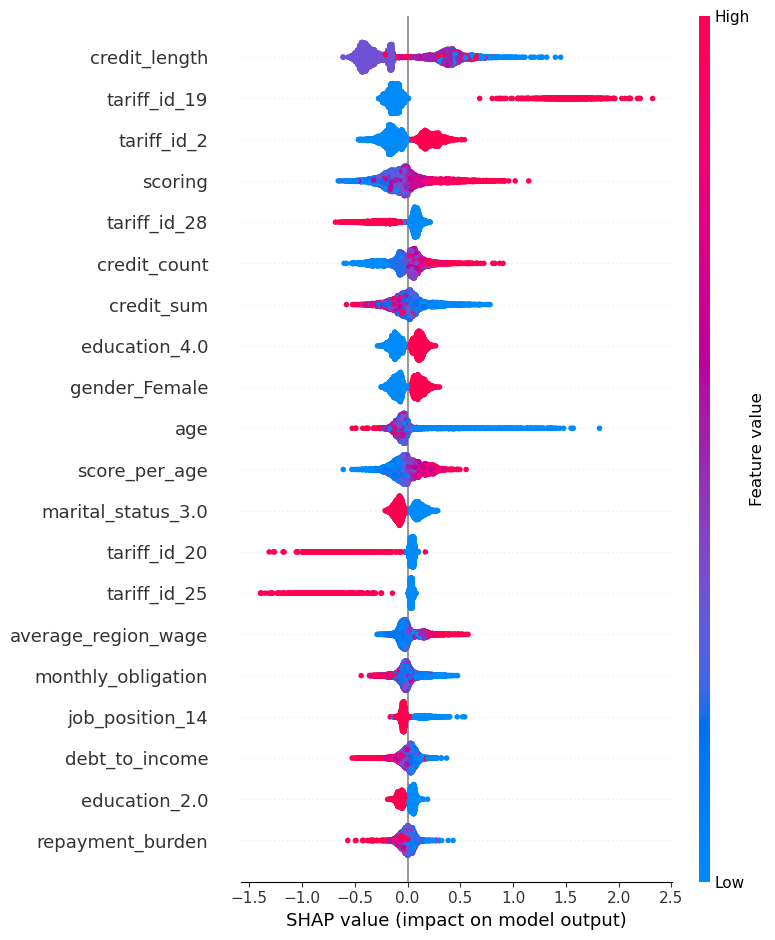

In [82]:
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=feature_names,
                  max_display=20)

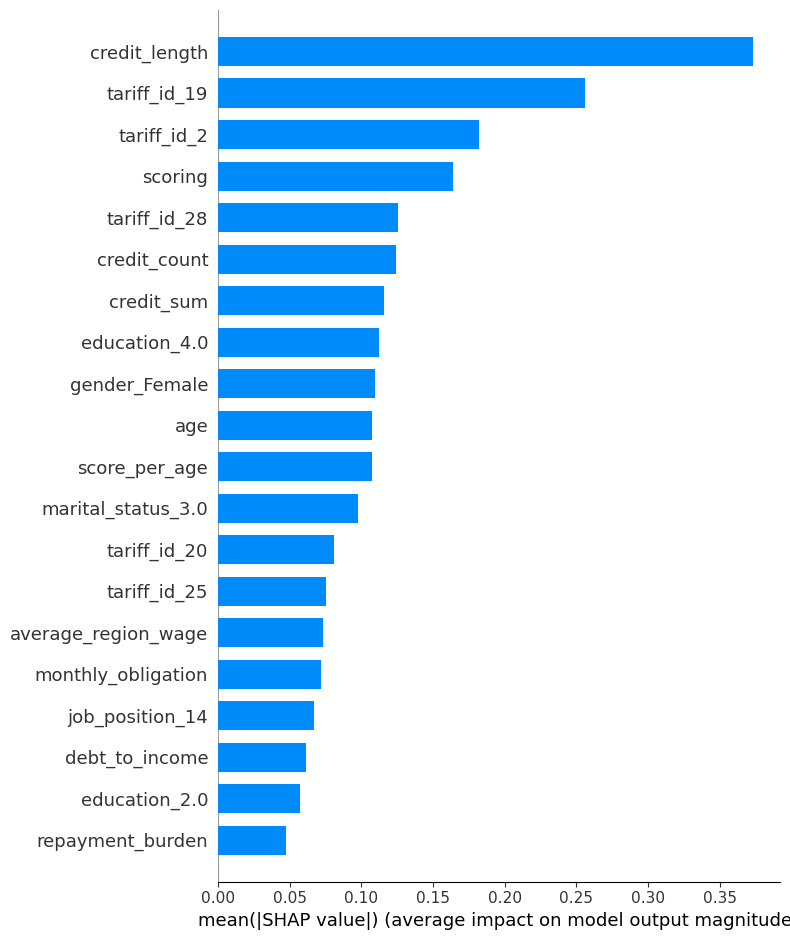

In [83]:
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=feature_names,
                  plot_type='bar',
                  max_display=20)

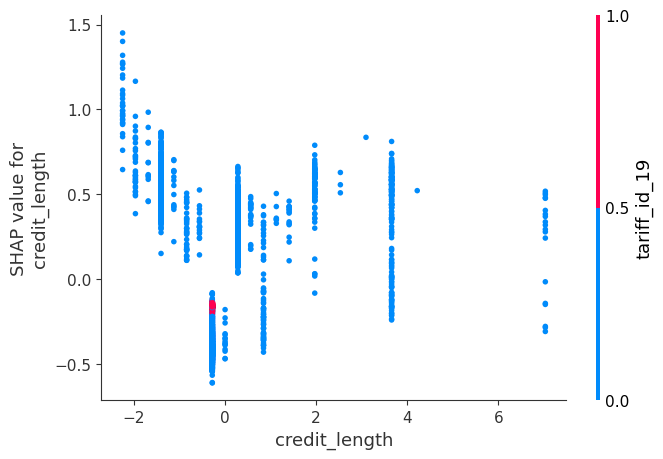

In [84]:
shap.dependence_plot('credit_length', shap_values, X_test_sample,
                     feature_names=feature_names)

## Lift and Gain analysis

In [85]:
def build_lift_table(y_true, y_prob, n_deciles=10):
    df = pd.DataFrame({'y': y_true.values, 'p': y_prob})
    df = df.sort_values('p', ascending=False).reset_index(drop=True)
    df['decile'] = pd.qcut(df.index, n_deciles, labels=False, duplicates='drop') + 1
    
    tbl = df.groupby('decile').agg(
        customers=('y', 'count'),
        churners =('y', 'sum'),
        avg_prob =('p', 'mean')
    ).reset_index()
    
    total_customers = tbl['customers'].sum()
    total_churners  = tbl['churners'].sum()
    overall_rate    = total_churners / total_customers
    
    tbl['churn_rate']       = tbl['churners'] / tbl['customers']
    tbl['cum_customers']    = tbl['customers'].cumsum()
    tbl['cum_churners']     = tbl['churners'].cumsum()
    tbl['cum_customer_pct'] = tbl['cum_customers'] / total_customers
    tbl['gain']             = tbl['cum_churners']  / total_churners
    tbl['lift']             = tbl['churn_rate']    / overall_rate
    tbl['cum_lift']         = tbl['gain']          / tbl['cum_customer_pct']
    
    return tbl

In [86]:
y_test_reset = y_test.reset_index(drop=True)

lift_tables = {}
for name, pipe in all_pipelines.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    lift_tables[name] = build_lift_table(y_test_reset, prob)

In [87]:
lift_tables['Stacking Ensemble'][[
    'decile', 'customers', 'churners', 'avg_prob',
    'churn_rate', 'gain', 'lift', 'cum_lift'
]]

,decile,customers,churners,avg_prob,churn_rate,gain,lift,cum_lift
0,1,3392,1594,0.47,0.47,0.27,2.65,2.65
1,2,3392,1142,0.36,0.34,0.46,1.90,2.28
2,3,3392,902,0.27,0.27,0.61,1.50,2.02
3,4,3391,685,0.20,0.20,0.72,1.14,1.80
4,5,3392,602,0.15,0.18,0.82,1.00,1.64
5,6,3392,394,0.11,0.12,0.88,0.66,1.47
6,7,3391,272,0.08,0.08,0.93,0.45,1.33
7,8,3392,206,0.06,0.06,0.96,0.34,1.21
8,9,3392,148,0.05,0.04,0.99,0.25,1.10
9,10,3392,66,0.03,0.02,1.00,0.11,1.00


In [117]:
lift_tables['XGBoost'][[
    'decile', 'customers', 'churners', 'avg_prob',
    'churn_rate', 'gain', 'lift', 'cum_lift'
]]

,decile,customers,churners,avg_prob,churn_rate,gain,lift,cum_lift
0,1,3392,1588,0.80,0.47,0.26,2.64,2.64
1,2,3392,1149,0.68,0.34,0.46,1.91,2.28
2,3,3392,907,0.60,0.27,0.61,1.51,2.02
3,4,3391,711,0.51,0.21,0.72,1.18,1.81
4,5,3392,572,0.42,0.17,0.82,0.95,1.64
5,6,3392,392,0.34,0.12,0.88,0.65,1.47
6,7,3391,258,0.28,0.08,0.93,0.43,1.33
7,8,3392,217,0.22,0.06,0.96,0.36,1.20
8,9,3392,151,0.17,0.04,0.99,0.25,1.10
9,10,3392,66,0.09,0.02,1.00,0.11,1.00


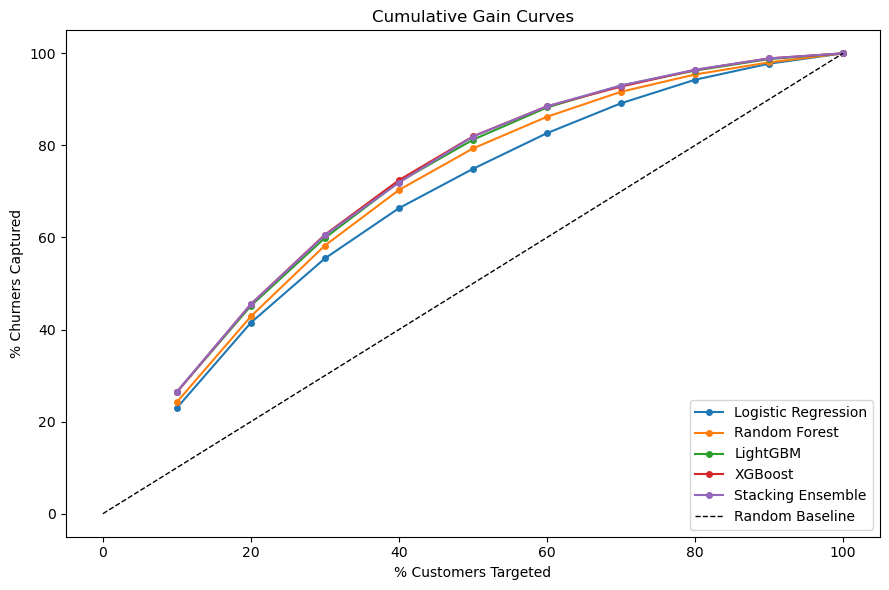

In [88]:
plt.figure(figsize=(9, 6))
colors = plt.cm.tab10.colors
for i, (name, tbl) in enumerate(lift_tables.items()):
    plt.plot(tbl['cum_customer_pct'] * 100, tbl['gain'] * 100,
             label=name, color=colors[i], marker='o', markersize=4)
plt.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random Baseline')
plt.xlabel('% Customers Targeted')
plt.ylabel('% Churners Captured')
plt.title('Cumulative Gain Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Profit optimization

**Define business parameters**

In [113]:
CLV = 15000             # value retained if churn prevented
Cost = 200              # intervention cost per customer
Success_rate = 0.2    # probability intervention prevents churn

In [114]:
def compute_profit_curve(y_true, y_prob, clv, cost, success_rate):
    df = pd.DataFrame({'y': y_true.values, 'p': y_prob})
    df = df.sort_values('p', ascending=False).reset_index(drop=True)
    df['expected_profit'] = df['p'] * success_rate * clv - cost
    df['cum_profit']      = df['expected_profit'].cumsum()
    df['target_pct']      = (df.index + 1) / len(df)
    return df

In [115]:
profit_curves  = {}
profit_summary = []

for name, pipe in all_pipelines.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    pf   = compute_profit_curve(y_test_reset, prob, CLV, Cost, Success_rate)
    profit_curves[name] = pf
    
    opt = pf.loc[pf['cum_profit'].idxmax()]
    profit_summary.append({
        'Model'           : name,
        'Max Profit (RUB)': round(opt['cum_profit'], 2),
        'Optimal Target %': round(opt['target_pct'] * 100, 1),
        'Prob Cutoff'     : round(opt['p'], 4),
    })

pd.DataFrame(profit_summary).sort_values('Max Profit (RUB)', ascending=False)

,Model,Max Profit (RUB),Optimal Target %,Prob Cutoff
0,Logistic Regression,39334137.19,99.80,0.07
3,XGBoost,35142280.00,97.60,0.07
2,LightGBM,33387863.89,94.40,0.07
4,Stacking Ensemble,11955410.20,72.40,0.07
1,Random Forest,11530335.75,77.50,0.07


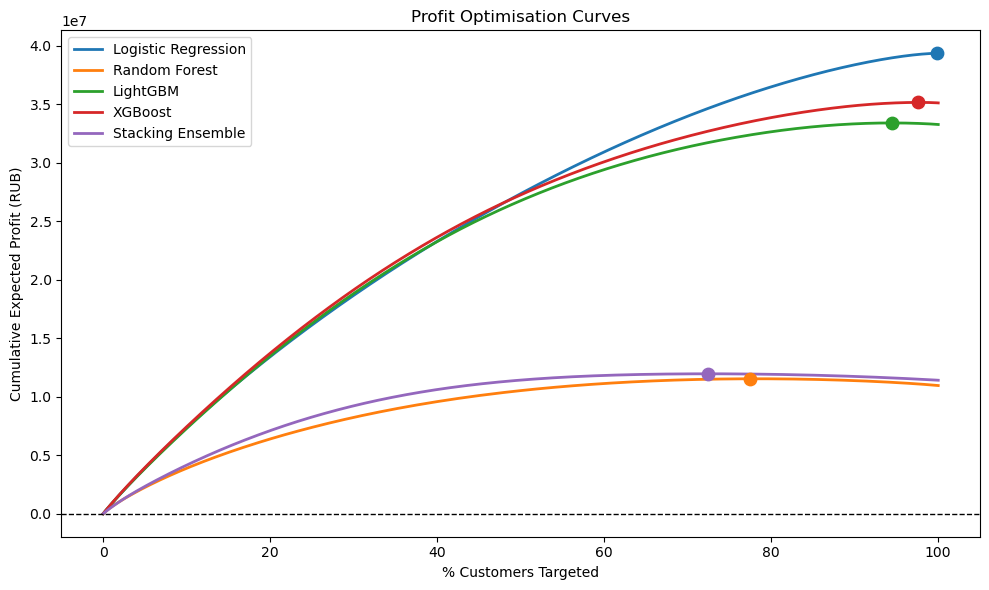

In [116]:
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10.colors
for i, (name, pf) in enumerate(profit_curves.items()):
    plt.plot(pf['target_pct'] * 100, pf['cum_profit'],
             label=name, color=colors[i], linewidth=2)
    opt = pf.loc[pf['cum_profit'].idxmax()]
    plt.scatter(opt['target_pct']*100, opt['cum_profit'],
                color=colors[i], s=80, zorder=5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('% Customers Targeted')
plt.ylabel('Cumulative Expected Profit (RUB)')
plt.title('Profit Optimisation Curves')
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
scenarios = {
    'Conservative (Low CLV)' : {'CLV': 1000,  'COST': 170, 'SUCCESS_RATE': 0.30},
    'Realistic (Market CLV)'  : {'CLV': 15000, 'COST': 200, 'SUCCESS_RATE': 0.20},
}

scenarios

{'Conservative (Low CLV)': {'CLV': 1000, 'COST': 170, 'SUCCESS_RATE': 0.3},
 'Realistic (Market CLV)': {'CLV': 15000, 'COST': 200, 'SUCCESS_RATE': 0.2}}

# Business insights and Recommendation

1. Model Selection:
- XGBoost was selected as the final deployment model for profit maximisation. The model achieves AUC score of 0.75 and a recall score of 75%. While Stacking Ensemble model achieved 3% higher recall score, its poorly calibrated probabilities required a very low optimal threshold (0.14), resulting in excessive false positives and significantly lower profit under cost-sensitive conditions.
- Under conservative business parameters (CLV=1,000 RUB, Cost=170 RUB, success rate=0.3), XGBoost maximises expected profit by targeting the top 28.7% highest-risk customers.
- However model selection depends on the business objective. When intervention costs are low relative to CLV, a wide-net strategy with Logistic Regression maximises profit. When costs are high relative to CLV, a precision-focused model like XGBoost is optimal. The right model is a business decision, not just a technical one.

2. Key Churn Drivers:
- `credit_length` is the top most important feature in this analysis, customers are more likely to churn with lower credit length. Hinting that short term loan customers have less financial commitment to the bank, making it easier to leave.
- `tariff_id_19` is the second more important feature. Clients under this tariff are more likely to churn. A review is needed for clients under this tariff to understand the product or pricing characteristics that affects them.
- `scoring` is also another important feature, but it shows a non-linear relationship with churn.
- `score_per_age`, `debt_to_income` and `monthly_obligation` shows up in top 20, they add predictive signal beyond raw features.
- Clients under `tariff_id_20`,`tariff_id_25`,`tariff_id_28` are less likely to churn. Hinting to be protective against customer churn, can be used as reference.

3. Lift Performance:
- Stacking ensemble is used for lift analysis with the best recall score of 78%, capturing more churners.
- Top 10% highest-risk customers are 2.65× more likely to churn than average, 165% improvement over random.
- Targeting the top 40% highest-risk customers captures 72% of all churners. This allows retention team to focus resource on less than half of the total customer base while recovering third quarter of potential churn losses. 

4. Profit Optimisation:
- As mentioned above, the model choice depends on the business decision as they are all sensitive to the business parameters.
  - Scenario 1: CLV = 1000, Cost = 170, Success rate= 0.3:
       - In this scenario, XGBoost gives the maximum profit 387293.16, by targetting top 28.70% highest risk customer. At these parameters, only customers with predicted churn probability above 57% are worth the intervention cost.
  - Scenario 2: CLV = 15000, Cost = 200, Success rate= 0.2:
       - In this realistic business parameter scenario, logistic regression gives the maximum profit, targetting 99.80% of customers, essentially everyone, since CLV is very high compared to cost.
- XGboost is recommended under conservative scenario where intervention budget is limited. Its precision-focused targeting ensures spending is concentrated on customers most likely to churn, maximising return on each intervention.

5. Recommendations:
- XGBoost is recommended for deployment via the REST API for real-time customer scoring and monthly batch campaign targeting.
- The bank is recommended to prioritise top 40% of highest risk customer for retention campaigns. This will capture 72% of possible churners, significantly improve market efficiency.
- A revise on tariff 19 is needed to study the cause, if there is, of customer churning. Tariff 20, 25, 28 shows to be protective from customer leaving. A further study in these tariffs is needed and replicate those characteristics in other products.
- The model should be monitored monthly by tracking AUC-ROC and KS statistic on recent scored customers. If KS drops below 0.35, retraining on fresh data is recommended to maintain predictive reliability.

# Model Serialisation

In [102]:
os.makedirs('models', exist_ok=True)

for name, pipe in all_pipelines.items():
    fname = f"models/{name.lower().replace(' ', '_')}_pipeline.joblib"
    joblib.dump(pipe, fname)
    print(f'Saved: {fname}')

Saved: models/logistic_regression_pipeline.joblib
Saved: models/random_forest_pipeline.joblib
Saved: models/lightgbm_pipeline.joblib
Saved: models/xgboost_pipeline.joblib
Saved: models/stacking_ensemble_pipeline.joblib


In [104]:
metadata = {
    'optimal_thresholds'  : optimal_thresholds,
    'feature_names'       : all_features,
    'numerical_features'  : num_features,
    'categorical_features': cat_features,
    'binary_features'     : bool_features,
    'best_model_auc'      : 'Stacking Ensemble',
    'best_model_profit'   : 'XGBoost',
    'profit_scenarios'    : scenarios,
}

joblib.dump(metadata, 'models/metadata.joblib')
print('Metadata saved.')

Metadata saved.
